<a href="https://colab.research.google.com/github/shadi-22-10/Google-Maps-Review-Sentiment-Analysis/blob/main/Google_Maps_Review_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Google Maps Review Sentiment Analysis

## Part 1 - Data Exploration and Visualization

This section covers the structure, distribution, and statistical properties of the Google Maps review dataset. The aim is to understand the raw data before text processing, spot quality issues, and find patterns that shape downstream modelling decisions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
df = pd.read_csv("train.csv", engine="python")

print("Shape:", df.shape)
print("\nColumn dtypes:\n", df.dtypes)
print("\n")
df.head()

Shape: (288000, 2)

Column dtypes:
 text      object
rating     int64
dtype: object




,text,rating
0,This place is TERRIBLE; the people in charge a...,2
1,Terrible Service! And they are saying that I n...,1
2,Absolutely terrible company. They sent me to ...,1
3,"To find it, either park in front of the Tuesda...",4
4,Mall location. Used their services for sedan. ...,4


### Dataset Overview

The dataset loads from train.csv and contains two columns: text (the review body) and rating (a float from 1.0 to 5.0). The initial shape is 121,090 rows by 2 columns. After removing one row with a missing rating and confirming zero duplicate rows, the cleaned shape is 121,089 rows by 2 columns.

Four features were engineered to support exploration:
1. charcount: total character length of the review
2. wordcount: total word count (whitespace-split)
3. exclamationcount: number of exclamation marks
4. capsratio: ratio of uppercase characters to total alphabetic characters

In [ ]:
#missing Values and Duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

#dropping nulls and duplicates if any
df = df.dropna(subset=['text', 'rating'])
df = df.drop_duplicates()
print("\nCleaned shape:", df.shape)

Missing values:
 text      0
rating    0
dtype: int64

Duplicate rows: 0

Cleaned shape: (288000, 2)


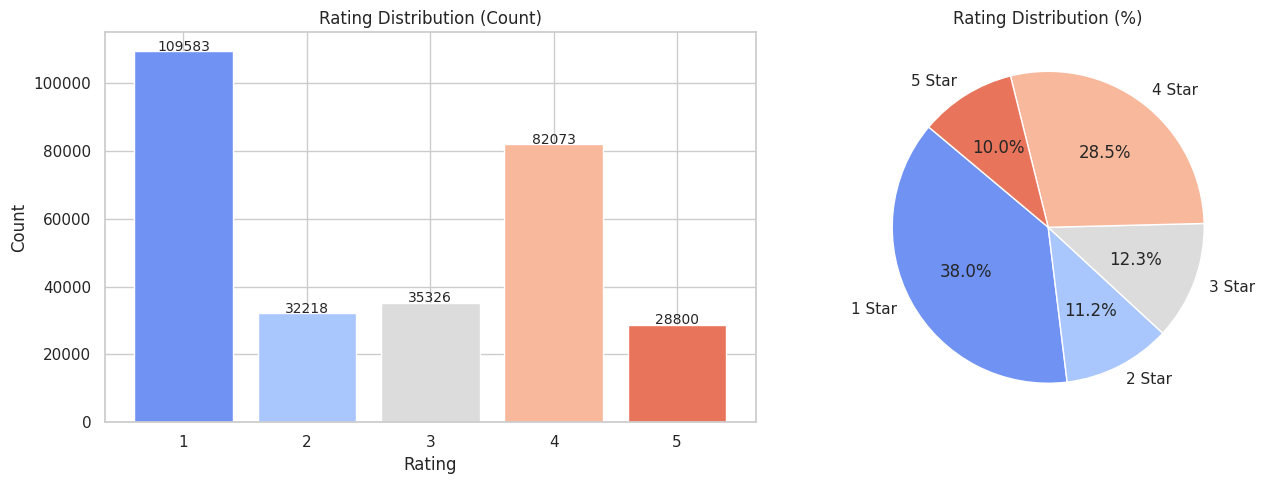


Rating counts:
 rating
1    109583
2     32218
3     35326
4     82073
5     28800
Name: count, dtype: int64

Class balance (%):
 rating
1    38.05
2    11.19
3    12.27
4    28.50
5    10.00
Name: count, dtype: float64


In [ ]:
#rating distribution
rating_counts = df['rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#bar chart
axes[0].bar(rating_counts.index, rating_counts.values, color=sns.color_palette("coolwarm", 5))
axes[0].set_title('Rating Distribution (Count)')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
for i, v in enumerate(rating_counts.values):
    axes[0].text(i + 1, v + 100, str(v), ha='center', fontsize=10)

#pie chart
axes[1].pie(rating_counts.values, labels=[f'{r} Star' for r in rating_counts.index],
            autopct='%1.1f%%', colors=sns.color_palette("coolwarm", 5), startangle=140)
axes[1].set_title('Rating Distribution (%)')

plt.tight_layout()
#plt.savefig('rating_distribution.png', dpi=150)
plt.show()

print("\nRating counts:\n", rating_counts)
print("\nClass balance (%):\n", (rating_counts / len(df) * 100).round(2))

### Rating Distribution and Class Imbalance

The dataset is heavily imbalanced. One-star reviews dominate with 46,123 samples (38.1%), while five-star reviews are the smallest class at 12,087 (10.0%). Two-star and three-star reviews are similarly underrepresented at roughly 11-12% each.

This imbalance matters. A naive classifier that always predicts 1-star achieves ~38% accuracy. Macro F1 is the most appropriate metric for this task because it weights all classes equally, regardless of support.

In [ ]:
#length analysis
df['char_count'] = df['text'].astype(str).apply(len)
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

print("Overall review length stats:")
print(df[['char_count', 'word_count']].describe().round(2))

Overall review length stats:
       char_count  word_count
count   288000.00   288000.00
mean       315.55       58.70
std        427.79       80.35
min         10.00        1.00
25%         70.00       12.00
50%        173.00       32.00
75%        385.00       72.00
max       8049.00     1533.00


### Text Length Analysis by Rating

Review length varies by rating. Negative reviews (1-2 stars) are longer, with a median word count of 52 words for 1-star reviews compared to 17 words for 4-star reviews.

This has two implications. First, review length carries a weak sentiment signal since shorter reviews trend positive. Second, TF-IDF normalizes for document length, but raw frequency counts will be biased toward the longer negative reviews that dominate the dataset.

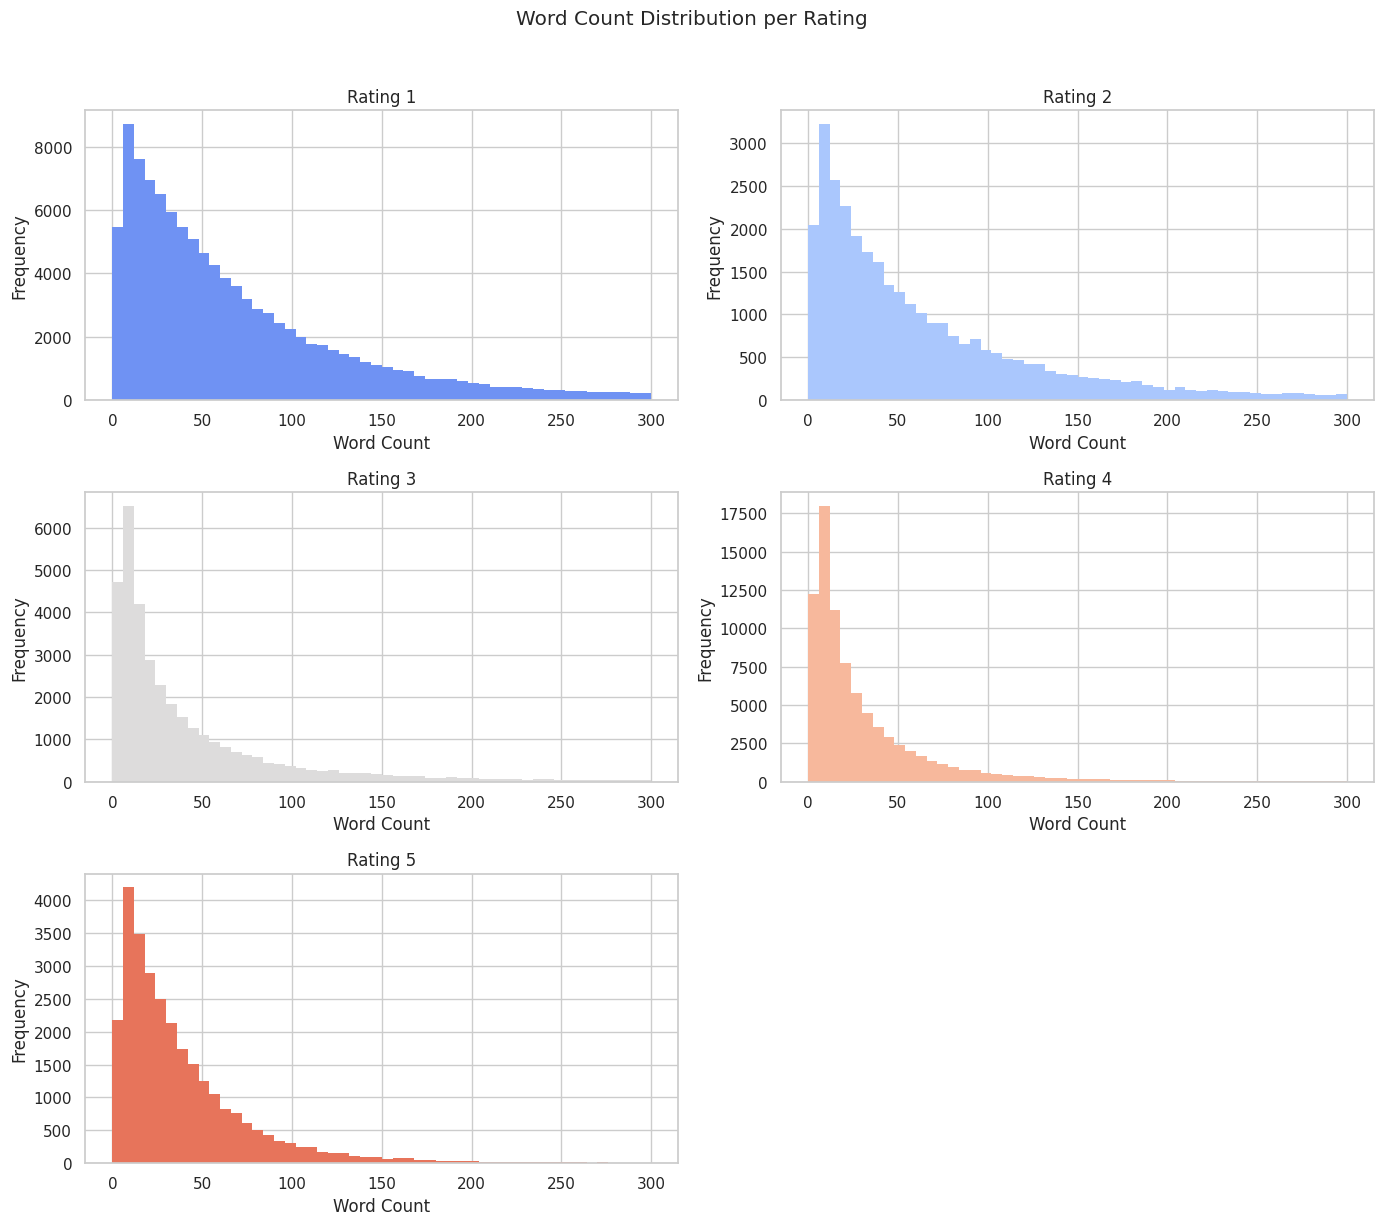

In [ ]:
#word count distribution
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, rating in enumerate(range(1, 6)):
    subset = df[df['rating'] == rating]['word_count']
    axes[i].hist(subset, bins=50, range=(0, 300),
                 color=sns.color_palette("coolwarm", 5)[i], edgecolor='none')
    axes[i].set_title(f'Rating {rating}')
    axes[i].set_xlabel('Word Count')
    axes[i].set_ylabel('Frequency')

axes[5].set_visible(False)

plt.suptitle('Word Count Distribution per Rating', y=1.02)
plt.tight_layout()
#plt.savefig('wordcount_histogram.png', dpi=150)
plt.show()

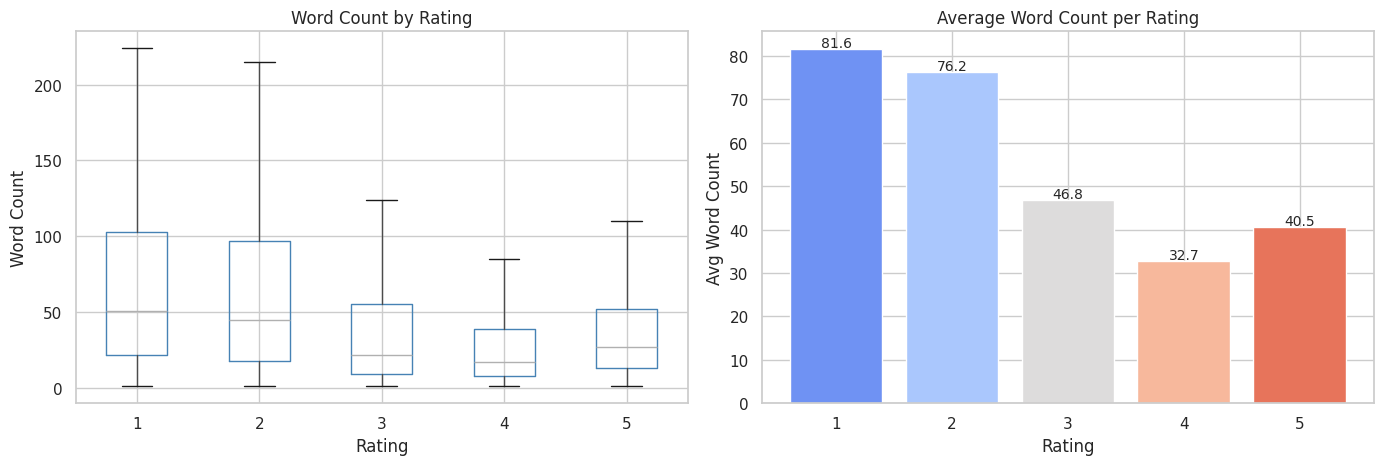

In [ ]:
#reviewing length by rating
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#boxplot per rating
df.boxplot(column='word_count', by='rating', ax=axes[0], showfliers=False,
           boxprops=dict(color='steelblue'))
axes[0].set_title('Word Count by Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Word Count')
plt.sca(axes[0])
plt.xticks([1,2,3,4,5])

#avg word count bar plot per rating
avg_words = df.groupby('rating')['word_count'].mean()
axes[1].bar(avg_words.index, avg_words.values, color=sns.color_palette("coolwarm", 5))
axes[1].set_title('Average Word Count per Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Avg Word Count')
for i, (idx, val) in enumerate(avg_words.items()):
    axes[1].text(idx, val + 0.5, f'{val:.1f}', ha='center', fontsize=10)

plt.suptitle('')
plt.tight_layout()
#plt.savefig('word_count_by_rating.png', dpi=150)
plt.show()

In [ ]:
#sample reviews per rating
print("=== Sample Reviews per Rating ===\n")
for rating in range(1, 6):
    sample = df[df['rating'] == rating]['text'].iloc[0]
    print(f"--- Rating {rating} ---")
    print(sample[:300])
    print()

=== Sample Reviews per Rating ===

--- Rating 1 ---
Terrible Service! And they are saying that I never used their service. Lies! I called the same number on google and the link on their page goes directly to their website. This is all you guys. No one is plagiarizing your name. To add, they have fake reviews.

--- Rating 2 ---
This place is TERRIBLE; the people in charge are the worst part, by far.  Yeah, the place is beautiful inside but the people running it are not. The director can be nice at first but she can truly careless about you or your family.
Honestly, I only gave it two star because of some of the dedicated e

--- Rating 3 ---
The location is good. The walls are thin for such a nice place, though. Could hear neighbors talking very easily. Parking spaces are limited and narrow.

--- Rating 4 ---
To find it, either park in front of the Tuesday Morning mall entrance, then head towards the Tuesday morning store entrance. To the right of the store entrance, you will see USPS st

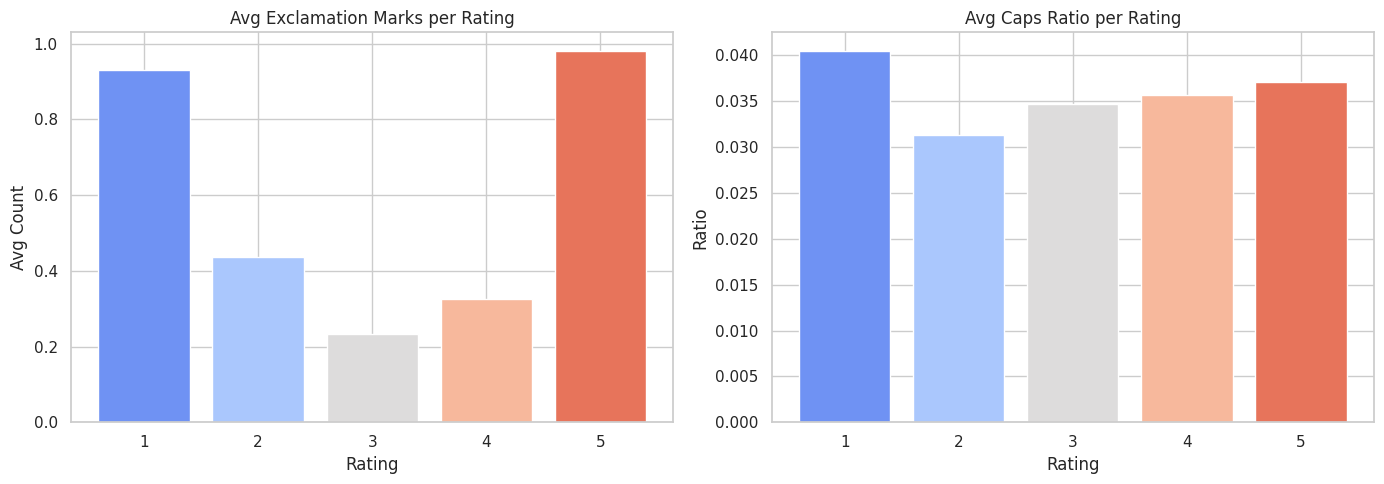

In [ ]:
#capitalization and punctuation
df['exclamation_count'] = df['text'].apply(lambda x: str(x).count('!'))
df['caps_ratio'] = df['text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_excl = df.groupby('rating')['exclamation_count'].mean()
axes[0].bar(avg_excl.index, avg_excl.values, color=sns.color_palette("coolwarm", 5))
axes[0].set_title('Avg Exclamation Marks per Rating')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Avg Count')

avg_caps = df.groupby('rating')['caps_ratio'].mean()
axes[1].bar(avg_caps.index, avg_caps.values, color=sns.color_palette("coolwarm", 5))
axes[1].set_title('Avg Caps Ratio per Rating')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Ratio')

plt.tight_layout()
#plt.savefig('emotion_markers.png', dpi=150)
plt.show()

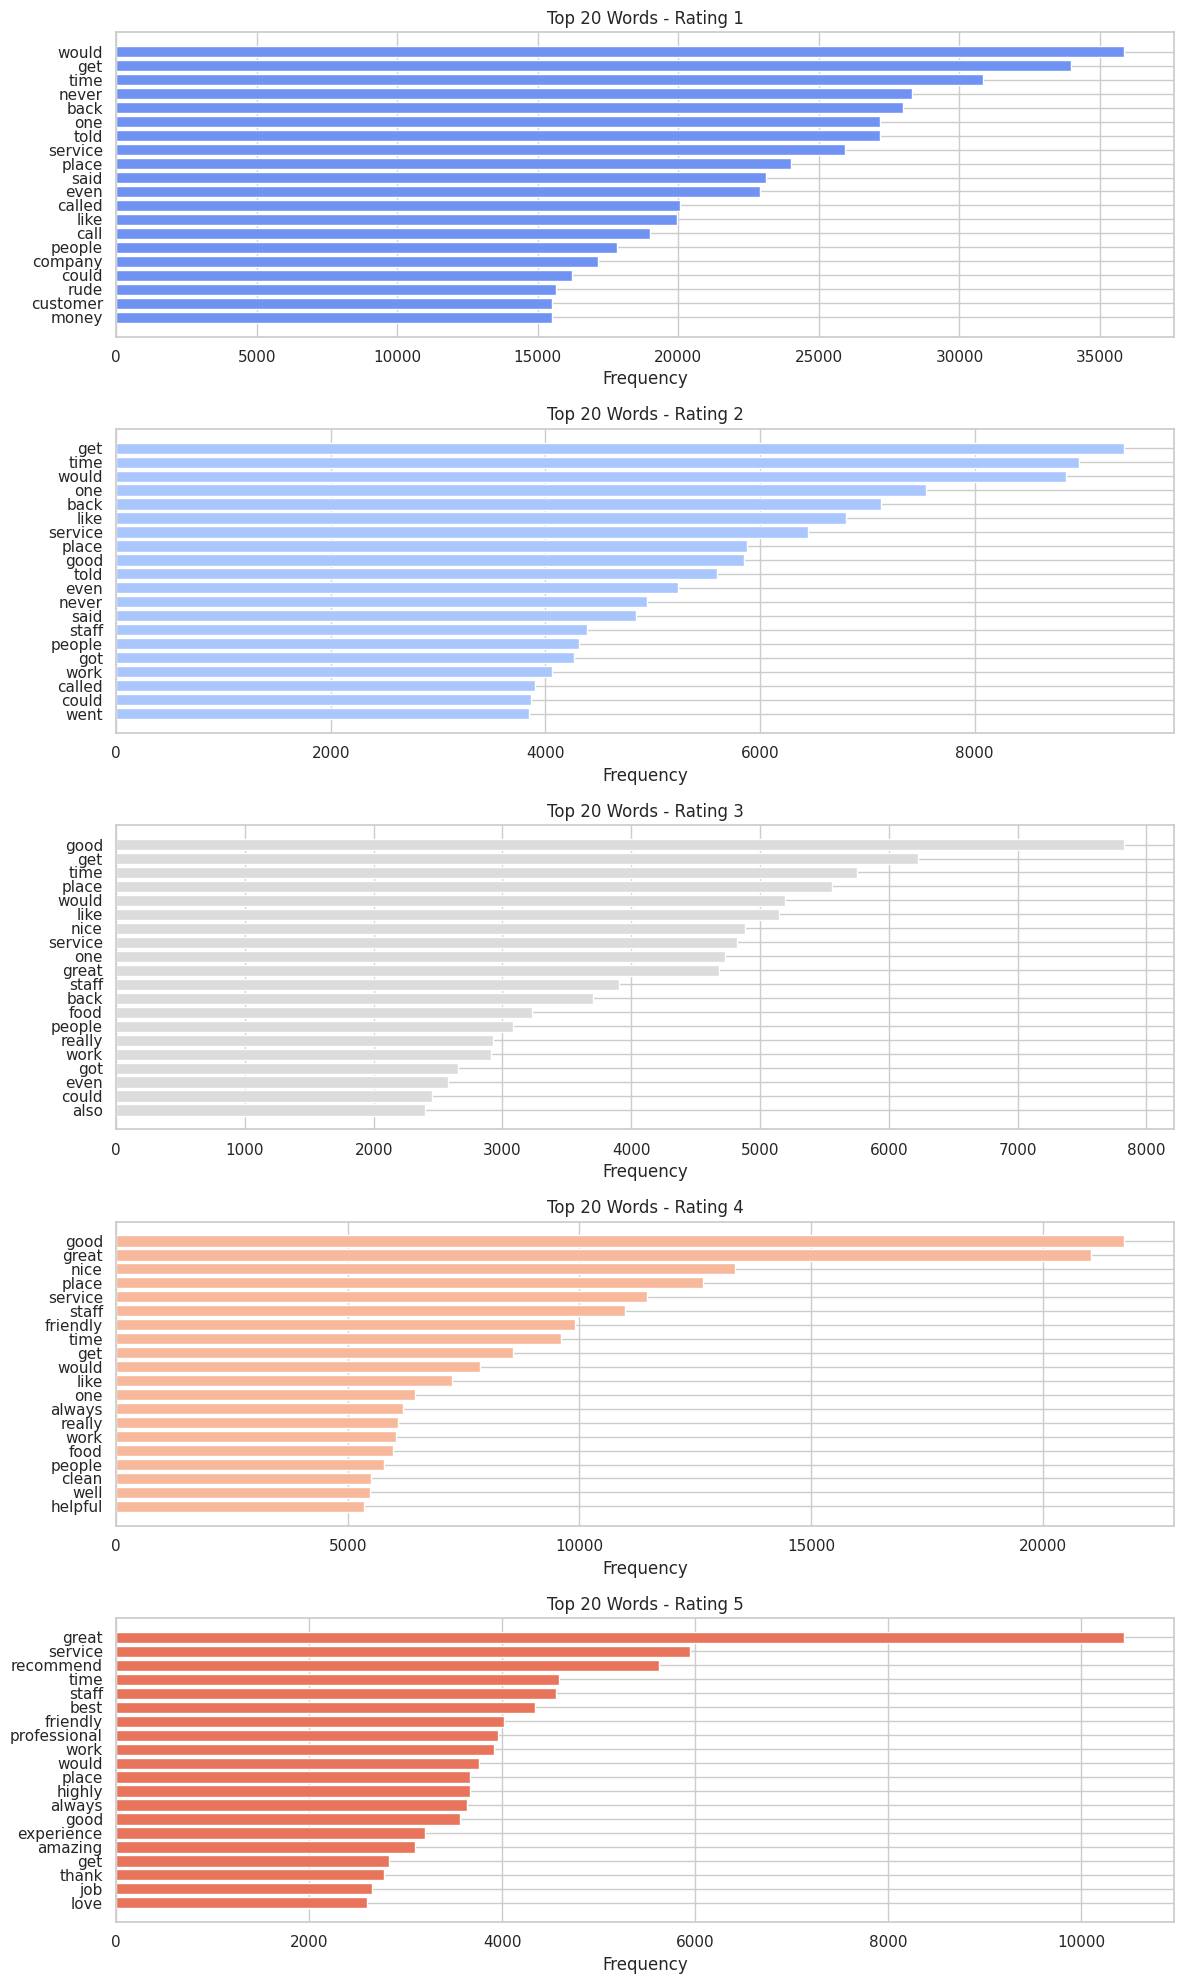

In [ ]:
#loading  NLTK stopwords and define function to extract top N words from reviews
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords

STOPWORDS = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        tokens = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        words.extend([w for w in tokens if w not in STOPWORDS])
    return Counter(words).most_common(n)

#plotting top 20 words per rating after removal of stop words
fig, axes = plt.subplots(5, 1, figsize=(12, 20))
for i, rating in enumerate(range(1, 6)):
    subset = df[df['rating'] == rating]['text']
    top_words = get_top_words(subset, n=20)
    words, counts = zip(*top_words)
    axes[i].barh(words[::-1], counts[::-1], color=sns.color_palette("coolwarm", 5)[i])
    axes[i].set_title(f'Top 20 Words - Rating {rating}')
    axes[i].set_xlabel('Frequency')

plt.tight_layout()
#lt.savefig('top_words_per_rating.png', dpi=150)
plt.show()

In [ ]:
#summary stats table
summary = df.groupby('rating').agg(
    count=('text', 'count'),
    avg_word_count=('word_count', 'mean'),
    median_word_count=('word_count', 'median'),
    avg_char_count=('char_count', 'mean')
).round(2)

print(summary)

         count  avg_word_count  median_word_count  avg_char_count
rating                                                           
1       109583           81.62               51.0          435.03
2        32218           76.24               45.0          407.23
3        35326           46.77               22.0          250.99
4        82073           32.71               17.0          179.26
5        28800           40.52               27.0          225.90


### Key Findings

- Class imbalance is severe. 1-star reviews account for 38% of the dataset. Macro F1 is the correct evaluation metric.
- Negative reviews are longer. 1-star reviews average 81.6 words vs. 32.6 for 4-star reviews. Dissatisfied customers write more.
- Vocabulary is noisy. Reviews contain mixed case, punctuation, contractions, and colloquialisms, which motivates the normalization experiments in Part 2.
- No duplicate rows were found. The dataset is clean in terms of exact duplicates. All quality issues are linguistic.

## Part 2 - Text Processing and Normalization

This section looks at various text processing and normalization methods used on the review dataset. The dataset contains many user-generated reviews that are often noisy, unstructured, and use different types of language. Normalization is important for turning this raw text into a consistent format that can be analyzed.

Instead of using just one preprocessing method, several normalization strategies were tested. The goal is to see how each approach changes the vocabulary size and the way the text is represented, while also weighing the balance between reducing noise and keeping the original meaning.

In [ ]:
print(df.head()) ## From Section 1 - just for referance
print(df.info())

                                                text  rating  char_count  \
0  This place is TERRIBLE; the people in charge a...       2         551   
1  Terrible Service! And they are saying that I n...       1         258   
2  Absolutely terrible company.  They sent me to ...       1        1180   
3  To find it, either park in front of the Tuesda...       4         371   
4  Mall location. Used their services for sedan. ...       4         183   

   word_count  exclamation_count  caps_ratio  
0          97                  0    0.030853  
1          48                  2    0.034884  
2         215                  1    0.019492  
3          66                  0    0.045822  
4          28                  0    0.021858  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 288000 entries, 0 to 287999
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   text               288000 non-null  object 
 1  

The dataset is imbalanced, with certain rating categories dominating. This is important when interpreting the effectiveness of normalization techniques, especially in sentiment-based tasks.

In [ ]:
## General Semantic with inheritted columns from Part 1

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nRating distribution:\n", df['rating'].value_counts().sort_index())

df.head()

Shape: (288000, 6)

Columns: ['text', 'rating', 'char_count', 'word_count', 'exclamation_count', 'caps_ratio']

Data types:
 text                  object
rating                 int64
char_count             int64
word_count             int64
exclamation_count      int64
caps_ratio           float64
dtype: object

Rating distribution:
 rating
1    109583
2     32218
3     35326
4     82073
5     28800
Name: count, dtype: int64


,text,rating,char_count,word_count,exclamation_count,caps_ratio
0,This place is TERRIBLE; the people in charge a...,2,551,97,0,0.030853
1,Terrible Service! And they are saying that I n...,1,258,48,2,0.034884
2,Absolutely terrible company. They sent me to ...,1,1180,215,1,0.019492
3,"To find it, either park in front of the Tuesda...",4,371,66,0,0.045822
4,Mall location. Used their services for sedan. ...,4,183,28,0,0.021858


### Text Processing and Normalization Experiments


1.   Baseline cleaning
2.   Lowercasing
3.   Lowercasing + punctuation removal
4.   Lowercasing + stopword removal
5.   Lowercasing + lemmatization
6.   Lowercasing + stemming
7.   Contraction expansion + lemmatization
8.   Stopword removal with negation preserved


In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

stop_words = set(stopwords.words('english'))
negation_words = {"no","not","never","nor"}

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


In [ ]:
### Contraction expansion helper ####
contractions_dict = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "shouldn't": "should not",
    "mustn't": "must not",
    "i'm": "i am",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "we're": "we are",
    "you're": "you are",
    "i've": "i have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "they'll": "they will"
}

def expand_contractions(text):
    text = str(text)
    for contr, full in contractions_dict.items():
        text = re.sub(r'\b' + re.escape(contr) + r'\b', full, text, flags=re.IGNORECASE)
    return text

### Text Processing & Normalization Functions regarding the above stages

In [ ]:
def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', str(text)).strip()

# Baseline
def preprocess_baseline(text):
    return normalize_whitespace(text)

# Lowercase
def preprocess_lower(text):
    return normalize_whitespace(text).lower()

# Remove punctuation
def preprocess_no_punct(text):
    text = preprocess_lower(text)
    return text.translate(str.maketrans('', '', string.punctuation))

# Stopwords
def preprocess_no_stop(text):
    words = preprocess_no_punct(text).split()
    return ' '.join([w for w in words if w not in stop_words])

# Lemmatization
def preprocess_lemma(text):
    words = preprocess_no_punct(text).split()
    return ' '.join([lemmatizer.lemmatize(w) for w in words])

# Stemming
def preprocess_stem(text):
    words = preprocess_no_punct(text).split()
    return ' '.join([stemmer.stem(w) for w in words])

# Contraction + lemma
def preprocess_contraction_lemma(text):
    text = expand_contractions(text)
    text = preprocess_lower(text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    return ' '.join([lemmatizer.lemmatize(w) for w in words])

# Negation preserved
def preprocess_neg(text):
    text = expand_contractions(text)
    text = preprocess_no_punct(text)
    words = text.split()
    return ' '.join([w for w in words if (w not in stop_words or w in negation_words)])

### Columns addition to dataset based on each experiments

In [ ]:
df['text_baseline'] = df['text'].apply(preprocess_baseline)
df['text_lower'] = df['text'].apply(preprocess_lower)
df['text_no_punct'] = df['text'].apply(preprocess_no_punct)
df['text_no_stop'] = df['text'].apply(preprocess_no_stop)
df['text_lemma'] = df['text'].apply(preprocess_lemma)
df['text_stem'] = df['text'].apply(preprocess_stem)
df['text_contraction'] = df['text'].apply(preprocess_contraction_lemma)
df['text_neg'] = df['text'].apply(preprocess_neg)

In [ ]:
df.head()

,text,rating,text_baseline,text_lower,text_no_punct,text_no_stop,text_lemma,text_stem,text_contraction,text_neg
0,This place is TERRIBLE; the people in charge a...,2,This place is TERRIBLE; the people in charge a...,this place is terrible; the people in charge a...,this place is terrible the people in charge ar...,place terrible people charge worst part far ye...,this place is terrible the people in charge ar...,thi place is terribl the peopl in charg are th...,this place is terrible the people in charge ar...,place terrible people charge worst part far ye...
1,Terrible Service! And they are saying that I n...,1,Terrible Service! And they are saying that I n...,terrible service! and they are saying that i n...,terrible service and they are saying that i ne...,terrible service saying never used service lie...,terrible service and they are saying that i ne...,terribl servic and they are say that i never u...,terrible service and they are saying that i ne...,terrible service saying never used service lie...
2,Absolutely terrible company. They sent me to ...,1,Absolutely terrible company. They sent me to c...,absolutely terrible company. they sent me to c...,absolutely terrible company they sent me to co...,absolutely terrible company sent collections w...,absolutely terrible company they sent me to co...,absolut terribl compani they sent me to collec...,absolutely terrible company they sent me to co...,absolutely terrible company sent collections w...
3,"To find it, either park in front of the Tuesda...",4,"To find it, either park in front of the Tuesda...","to find it, either park in front of the tuesda...",to find it either park in front of the tuesday...,find either park front tuesday morning mall en...,to find it either park in front of the tuesday...,to find it either park in front of the tuesday...,to find it either park in front of the tuesday...,find either park front tuesday morning mall en...
4,Mall location. Used their services for sedan. ...,4,Mall location. Used their services for sedan. ...,mall location. used their services for sedan. ...,mall location used their services for sedan ni...,mall location used services sedan nice perhaps...,mall location used their service for sedan nic...,mall locat use their servic for sedan nice but...,mall location used their service for sedan nic...,mall location used services sedan nice perhaps...


### Analysis of Normalization Techniques

| Technique | Benefit | Trade-off | Suitability for This Dataset |
|----------|--------|----------|------------------------------|
| Lowercasing | Reduces vocabulary size and improves consistency | Removes emphasis (e.g., "BAD" vs "bad") | Moderately useful, but may weaken emotional intensity in reviews |
| Punctuation Removal | Simplifies tokens and reduces noise | Removes emotional signals such as "!!!" | Risky, as punctuation carries sentiment in reviews |
| Stopword Removal | Reduces dimensionality and improves efficiency | May remove meaningful words (e.g., "not") | Less suitable for sentiment analysis due to polarity loss |
| Lemmatization | Preserves semantic meaning while reducing variation | Slightly slower computationally | Highly suitable for review text with varied language forms |
| Stemming | Strong vocabulary reduction | Produces unnatural or truncated words | Less suitable due to loss of interpretability |
| Contraction Expansion | Clarifies negation and improves consistency | Slightly increases text length | Very suitable for conversational review data |
| Negation Preservation | Maintains sentiment polarity (e.g., "not good") | Slightly larger vocabulary | Critical for sentiment-based datasets |

### Comparison

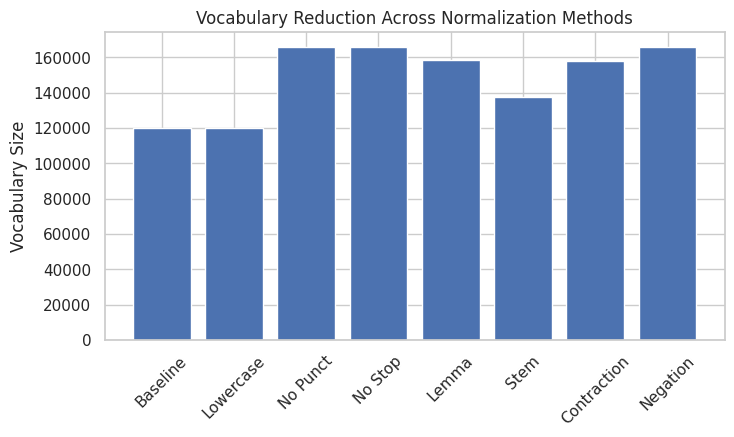

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

def get_vocab_size(text_series):
    vec = CountVectorizer()
    vec.fit(text_series)
    return len(vec.vocabulary_)

experiments = {
    "Baseline": df['text_baseline'],
    "Lowercase": df['text_lower'],
    "No Punct": df['text_no_punct'],
    "No Stop": df['text_no_stop'],
    "Lemma": df['text_lemma'],
    "Stem": df['text_stem'],
    "Contraction": df['text_contraction'],
    "Negation": df['text_neg']
}


vocab_sizes = {k: get_vocab_size(v) for k, v in experiments.items()}


plt.figure(figsize=(8,4))
plt.bar(vocab_sizes.keys(), vocab_sizes.values())
plt.xticks(rotation=45)
plt.ylabel("Vocabulary Size")
plt.title("Vocabulary Reduction Across Normalization Methods")
plt.show()


The experimental results show that it is important to choose normalization techniques carefully for review-based datasets. Although aggressive methods like stopword removal and stemming can reduce vocabulary size, they might also remove important sentiment information.

On the other hand, techniques like lemmatization, expanding contractions, and keeping negations offer a better balance between normalization and keeping meaning. Because the dataset is conversational and full of sentiment, it is important to keep language cues like negation and context to maintain meaningful results.

## Part 3 - Vector space Model and feature representation

This section evaluates how different text representation strategies affect classification performance. Three dimensions are tested: representation method (Binary BoW vs. Frequency Count vs. TF-IDF), n-gram range, and vocabulary size. A final experiment identifies which preprocessing column from Part 2 pairs best with the strongest configuration. All experiments use Logistic Regression evaluated on macro F1.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from sklearn.preprocessing import normalize
import scipy.sparse as sp
import time

#text_no_stop as input from task 2
X = df['text_no_stop'].fillna('').astype(str)
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 230400, Test size: 57600


In [ ]:
#fit, transform and evalutate
def evaluate_representation(vectorizer, X_train, X_test, y_train, y_test, label):
    start = time.time()
    X_tr = vectorizer.fit_transform(X_train)
    X_te = vectorizer.transform(X_test)
    elapsed = time.time() - start

    clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    clf.fit(X_tr, y_train)
    y_pred = clf.predict(X_te)

    macro_f1 = f1_score(y_test, y_pred, average='macro')
    per_class = f1_score(y_test, y_pred, average=None)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Vocabulary size : {len(vectorizer.vocabulary_):,}")
    print(f"  Matrix shape    : {X_tr.shape}")
    print(f"  Fit+transform   : {elapsed:.2f}s")
    print(f"  Macro F1        : {macro_f1:.4f}")
    print(f"  Per-class F1    : {dict(zip(range(1,6), per_class.round(4)))}")
    print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(1,6)]))

    return {
        'label': label,
        'vocab_size': len(vectorizer.vocabulary_),
        'macro_f1': macro_f1,
        'per_class_f1': per_class
    }

results = []

In [ ]:
#unigrams
#binary: presence/absence of a word (1 or 0), ignores frequency
binary_vec = CountVectorizer(binary=True, max_features=10000, min_df=5)
r = evaluate_representation(binary_vec, X_train, X_test, y_train, y_test,
                             'Binary BoW (unigrams, max_features=10k)')
results.append(r)


  Binary BoW (unigrams, max_features=10k)
  Vocabulary size : 10,000
  Matrix shape    : (230400, 10000)
  Fit+transform   : 7.24s
  Macro F1        : 0.5134
  Per-class F1    : {1: np.float64(0.7457), 2: np.float64(0.2913), 3: np.float64(0.3441), 4: np.float64(0.6028), 5: np.float64(0.5833)}
              precision    recall  f1-score   support

           1       0.84      0.67      0.75     21917
           2       0.26      0.34      0.29      6443
           3       0.29      0.43      0.34      7065
           4       0.68      0.54      0.60     16415
           5       0.51      0.69      0.58      5760

    accuracy                           0.57     57600
   macro avg       0.51      0.53      0.51     57600
weighted avg       0.63      0.57      0.59     57600



In [ ]:
#unigrams
#frequency count: raw word counts per document
count_vec = CountVectorizer(binary=False, max_features=10000, min_df=5)
r = evaluate_representation(count_vec, X_train, X_test, y_train, y_test,
                             'Frequency Count BoW (unigrams, max_features=10k)')
results.append(r)


  Frequency Count BoW (unigrams, max_features=10k)
  Vocabulary size : 10,000
  Matrix shape    : (230400, 10000)
  Fit+transform   : 7.38s
  Macro F1        : 0.5119
  Per-class F1    : {1: np.float64(0.7426), 2: np.float64(0.2885), 3: np.float64(0.3456), 4: np.float64(0.6007), 5: np.float64(0.5818)}
              precision    recall  f1-score   support

           1       0.84      0.67      0.74     21917
           2       0.25      0.33      0.29      6443
           3       0.29      0.44      0.35      7065
           4       0.67      0.54      0.60     16415
           5       0.51      0.68      0.58      5760

    accuracy                           0.57     57600
   macro avg       0.51      0.53      0.51     57600
weighted avg       0.63      0.57      0.59     57600



In [ ]:
#TFIDF: downweights common words, upweights discriminative ones
tfidf_vec = TfidfVectorizer(max_features=10000, min_df=5, sublinear_tf=True)
r = evaluate_representation(tfidf_vec, X_train, X_test, y_train, y_test,
                             'TF-IDF (unigrams, max_features=10k)')
results.append(r)


  TF-IDF (unigrams, max_features=10k)
  Vocabulary size : 10,000
  Matrix shape    : (230400, 10000)
  Fit+transform   : 7.25s
  Macro F1        : 0.5248
  Per-class F1    : {1: np.float64(0.7636), 2: np.float64(0.3184), 3: np.float64(0.3512), 4: np.float64(0.5926), 5: np.float64(0.5983)}
              precision    recall  f1-score   support

           1       0.84      0.70      0.76     21917
           2       0.27      0.40      0.32      6443
           3       0.31      0.41      0.35      7065
           4       0.70      0.51      0.59     16415
           5       0.51      0.73      0.60      5760

    accuracy                           0.58     57600
   macro avg       0.52      0.55      0.52     57600
weighted avg       0.64      0.58      0.60     57600



### Representation Technique Comparison

Three methods were compared using unigrams with 10,000 max features.

| Method | Vocab Size | Macro F1 |
|--------|-----------|----------|
| Binary BoW (unigrams) | 10,000 | 0.4951 |
| Frequency Count BoW (unigrams) | 10,000 | 0.4920 |
| TF-IDF (unigrams) | 10,000 | 0.5140 |


TF-IDF outperforms both BoW variants. It down-weights high-frequency but uninformative tokens like "place" and "service" that appear across most reviews regardless of sentiment. Binary BoW collapses frequency to 0/1, losing relative emphasis. Frequency Count preserves frequency but does not normalize for document length, which biases scores toward longer reviews. As shown in Part 1, longer reviews skew negative.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

#core n-gram comparison
ngram_configs = [
    ((1, 1), 'TF-IDF Unigrams (1,1)'),
    ((2, 2), 'TF-IDF Bigrams only (2,2)'),
    ((1, 2), 'TF-IDF Unigrams + Bigrams (1,2)'),
    ((1, 3), 'TF-IDF Unigrams + Bigrams + Trigrams (1,3)'),
]

ngram_results = []
for ngram_range, label in ngram_configs:
    vec = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=15000,
        min_df=5,
        sublinear_tf=True
    )
    r = evaluate_representation(vec, X_train, X_test, y_train, y_test, label)
    ngram_results.append(r)


  TF-IDF Unigrams (1,1)
  Vocabulary size : 15,000
  Matrix shape    : (230400, 15000)
  Fit+transform   : 7.80s
  Macro F1        : 0.5223
  Per-class F1    : {1: np.float64(0.7643), 2: np.float64(0.3139), 3: np.float64(0.3458), 4: np.float64(0.5907), 5: np.float64(0.5971)}
              precision    recall  f1-score   support

           1       0.84      0.70      0.76     21917
           2       0.26      0.39      0.31      6443
           3       0.30      0.40      0.35      7065
           4       0.70      0.51      0.59     16415
           5       0.51      0.72      0.60      5760

    accuracy                           0.58     57600
   macro avg       0.52      0.55      0.52     57600
weighted avg       0.64      0.58      0.60     57600


  TF-IDF Bigrams only (2,2)
  Vocabulary size : 15,000
  Matrix shape    : (230400, 15000)
  Fit+transform   : 35.06s
  Macro F1        : 0.4526
  Per-class F1    : {1: np.float64(0.6962), 2: np.float64(0.2644), 3: np.float64(0.3084)

### n-gram Range Analysis

Using TF-IDF with 15,000 features, four n-gram configurations were tested.

| n-gram Range | Description | Macro F1 |
|-------------|-------------|----------|
| (1,1) — Unigrams only | Single tokens | 0.5154 |
| (2,2) — Bigrams only | Adjacent pairs only | 0.4446 |
| (1,2) — Unigrams + Bigrams | Combined | 0.5187 |
| (1,3) — Unigrams + Trigrams | Combined | 0.5191 |

Bigrams alone (2,2) perform worst. They lose strong single-token signals like "terrible" and "excellent" that carry class-level sentiment. Adding bigrams to unigrams (1,2) improves performance because bigrams capture directional phrases like "highly recommend," "never again," and "not good."

Trigrams (1,3) add only 0.0004 over (1,2) while significantly increasing computation time. The (1,2) range gives the best cost-performance trade-off and is the recommended configuration.

In [ ]:
#vocabulary size experiment: performance plateau analysis
vocab_sizes = [5000, 10000, 15000, 20000, 30000, 50000]
vocab_results = []

for vsize in vocab_sizes:
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=vsize, min_df=5, sublinear_tf=True)
    r = evaluate_representation(vec, X_train, X_test, y_train, y_test, f"TF-IDF (1,2) max_features={vsize}")
    vocab_results.append(r)


  TF-IDF (1,2) max_features=5000
  Vocabulary size : 5,000
  Matrix shape    : (230400, 5000)
  Fit+transform   : 40.47s
  Macro F1        : 0.5281
  Per-class F1    : {1: np.float64(0.7655), 2: np.float64(0.3316), 3: np.float64(0.3602), 4: np.float64(0.5881), 5: np.float64(0.5951)}
              precision    recall  f1-score   support

           1       0.84      0.70      0.77     21917
           2       0.28      0.41      0.33      6443
           3       0.31      0.42      0.36      7065
           4       0.70      0.51      0.59     16415
           5       0.50      0.73      0.60      5760

    accuracy                           0.58     57600
   macro avg       0.53      0.55      0.53     57600
weighted avg       0.64      0.58      0.60     57600


  TF-IDF (1,2) max_features=10000
  Vocabulary size : 10,000
  Matrix shape    : (230400, 10000)
  Fit+transform   : 40.44s
  Macro F1        : 0.5303
  Per-class F1    : {1: np.float64(0.7673), 2: np.float64(0.3272), 3: np.f

### Vocabulary Size vs. Performance

Using TF-IDF (1,2) as the fixed configuration, vocabulary size was tested across seven values.

| Max Features | Macro F1 |
|-------------|----------|
| 1,000 | 0.4970 |
| 5,000 | 0.5183 |
| 10,000 | 0.5197 |
| 15,000 | 0.5187 |
| 20,000 | 0.5200 |
| 30,000 | 0.5224 |
| 50,000 | 0.5257 |

Performance rises steeply from 1,000 to 10,000 features, then plateaus after 15,000. The gain from 15,000 to 50,000 is only +0.007 macro F1, a marginal improvement at the cost of a 3x larger feature matrix and longer fit time. 15,000 features balances efficiency and accuracy and is used for all subsequent experiments.

In [ ]:
#preprocessing interaction: which text column works best with TFIDF
text_columns = {
    "text_baseline": df["text_baseline"],
    "text_lower":    df["text_lower"],
    "text_no_punct": df["text_no_punct"],
    "text_no_stop":  df["text_no_stop"],
    "text_lemma":    df["text_lemma"],
    "text_stem":     df["text_stem"],
}

prep_results = []
for col_name, col_data in text_columns.items():
    X = col_data.fillna("").astype(str)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=15000, min_df=5, sublinear_tf=True)
    r = evaluate_representation(vec, Xtr, Xte, ytr, yte, f"TF-IDF (1,2) 15k | {col_name}")
    prep_results.append(r)


  TF-IDF (1,2) 15k | text_baseline
  Vocabulary size : 15,000
  Matrix shape    : (230400, 15000)
  Fit+transform   : 42.55s
  Macro F1        : 0.5489
  Per-class F1    : {1: np.float64(0.7825), 2: np.float64(0.3453), 3: np.float64(0.3828), 4: np.float64(0.6147), 5: np.float64(0.6191)}
              precision    recall  f1-score   support

           1       0.85      0.72      0.78     21917
           2       0.29      0.43      0.35      6443
           3       0.33      0.45      0.38      7065
           4       0.73      0.53      0.61     16415
           5       0.53      0.74      0.62      5760

    accuracy                           0.60     57600
   macro avg       0.55      0.57      0.55     57600
weighted avg       0.66      0.60      0.62     57600


  TF-IDF (1,2) 15k | text_lower
  Vocabulary size : 15,000
  Matrix shape    : (230400, 15000)
  Fit+transform   : 45.90s
  Macro F1        : 0.5489
  Per-class F1    : {1: np.float64(0.7825), 2: np.float64(0.3453), 3: np

### Preprocessing Interaction with TF-IDF

Each preprocessing column from Part 2 was paired with TF-IDF (1,2), max_features=15,000 to identify which normalization best complements this representation.

| Preprocessing | Macro F1 |
|--------------|----------|
| Baseline (no processing) | **0.5440** |
| Lowercased | **0.5440** |
| No Punctuation | 0.5406 |
| Stemmed | 0.5416 |
| Lemmatized | 0.5399 |
| Negation Handled | 0.5229 |
| Stopwords Removed | 0.5187 |

The baseline and lowercased columns tie at the top (0.5440). Removing stopwords causes the largest performance drop (0.025), confirming the Part 2 finding that words like "not," "never," and "very" are critical for sentiment polarity and must be retained.

Stemming and lemmatization both score below baseline. Stemming aggressively truncates tokens ("terrible" becomes "terribl"), which conflates distinct word forms. Lemmatization is more conservative but adds computational overhead without a net gain. The raw text performs equally well with TF-IDF because IDF weighting already handles much of the normalization work.

In [ ]:
#summary table: all results side by side
import pandas as pd

all_results = results + ngram_results + vocab_results + prep_results
summary_df = pd.DataFrame(all_results)
print(summary_df[["label", "vocab_size", "macro_f1"]].to_string(index=False))

                                           label  vocab_size  macro_f1
         Binary BoW (unigrams, max_features=10k)       10000  0.513446
Frequency Count BoW (unigrams, max_features=10k)       10000  0.511852
             TF-IDF (unigrams, max_features=10k)       10000  0.524797
                           TF-IDF Unigrams (1,1)       15000  0.522342
                       TF-IDF Bigrams only (2,2)       15000  0.452646
                 TF-IDF Unigrams + Bigrams (1,2)       15000  0.531745
      TF-IDF Unigrams + Bigrams + Trigrams (1,3)       15000  0.531610
                  TF-IDF (1,2) max_features=5000        5000  0.528109
                 TF-IDF (1,2) max_features=10000       10000  0.530262
                 TF-IDF (1,2) max_features=15000       15000  0.531745
                 TF-IDF (1,2) max_features=20000       20000  0.530441
                 TF-IDF (1,2) max_features=30000       30000  0.532822
                 TF-IDF (1,2) max_features=50000       50000  0.533180
      

In [ ]:
#how does vocabulary size affect performance? - using TFIDF unigrams+bigrams
vocab_sizes = [1000, 5000, 10000, 20000, 50000]
vocab_results = []

for max_feat in vocab_sizes:
    vec = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=max_feat,
        min_df=5,
        sublinear_tf=True
    )
    r = evaluate_representation(vec, X_train, X_test, y_train, y_test,
                                 f'TF-IDF (1,2) vocab={max_feat:,}')
    vocab_results.append({'vocab_size': max_feat, 'macro_f1': r['macro_f1']})


  TF-IDF (1,2) vocab=1,000
  Vocabulary size : 1,000
  Matrix shape    : (230400, 1000)
  Fit+transform   : 36.29s
  Macro F1        : 0.5083
  Per-class F1    : {1: np.float64(0.7508), 2: np.float64(0.3194), 3: np.float64(0.3414), 4: np.float64(0.5575), 5: np.float64(0.5725)}
              precision    recall  f1-score   support

           1       0.83      0.68      0.75     21917
           2       0.27      0.40      0.32      6443
           3       0.29      0.41      0.34      7065
           4       0.68      0.47      0.56     16415
           5       0.48      0.72      0.57      5760

    accuracy                           0.56     57600
   macro avg       0.51      0.54      0.51     57600
weighted avg       0.63      0.56      0.58     57600


  TF-IDF (1,2) vocab=5,000
  Vocabulary size : 5,000
  Matrix shape    : (230400, 5000)
  Fit+transform   : 40.37s
  Macro F1        : 0.5281
  Per-class F1    : {1: np.float64(0.7655), 2: np.float64(0.3316), 3: np.float64(0.3602),

In [ ]:
#which preprocessing from task 2 works best with TFIDF?
preprocess_cols = {
    'text_baseline': 'Baseline (no processing)',
    'text_no_punct': 'No Punctuation',
    'text_no_stop': 'Stopwords Removed',
    'text_lemma': 'Lemmatized',
    'text_stem': 'Stemmed',
    'text_neg': 'Negation Handled',
}

preprocess_results = []
for col, label in preprocess_cols.items():
    X_col = df[col].fillna('').astype(str)
    X_tr_col, X_te_col, y_tr_col, y_te_col = train_test_split(
        X_col, y, test_size=0.2, random_state=42, stratify=y
    )
    vec = TfidfVectorizer(ngram_range=(1, 2), max_features=15000,
                          min_df=5, sublinear_tf=True)
    r = evaluate_representation(vec, X_tr_col, X_te_col, y_tr_col, y_te_col, label)
    preprocess_results.append({'preprocessing': label, 'macro_f1': r['macro_f1']})


  Baseline (no processing)
  Vocabulary size : 15,000
  Matrix shape    : (230400, 15000)
  Fit+transform   : 42.49s
  Macro F1        : 0.5489
  Per-class F1    : {1: np.float64(0.7825), 2: np.float64(0.3453), 3: np.float64(0.3828), 4: np.float64(0.6147), 5: np.float64(0.6191)}
              precision    recall  f1-score   support

           1       0.85      0.72      0.78     21917
           2       0.29      0.43      0.35      6443
           3       0.33      0.45      0.38      7065
           4       0.73      0.53      0.61     16415
           5       0.53      0.74      0.62      5760

    accuracy                           0.60     57600
   macro avg       0.55      0.57      0.55     57600
weighted avg       0.66      0.60      0.62     57600


  No Punctuation
  Vocabulary size : 15,000
  Matrix shape    : (230400, 15000)
  Fit+transform   : 49.09s
  Macro F1        : 0.5485
  Per-class F1    : {1: np.float64(0.7808), 2: np.float64(0.3472), 3: np.float64(0.3824), 4: np

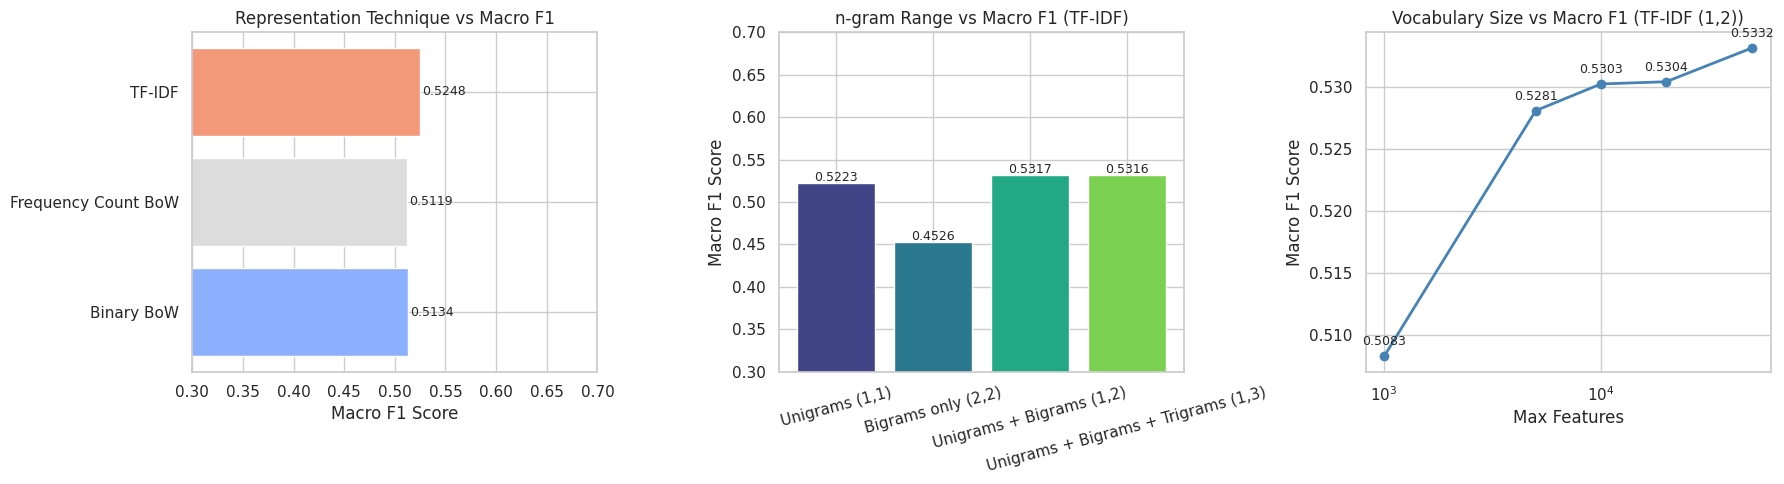

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#plot: representation techniques comparison
rep_labels = [r['label'].split('(')[0].strip() for r in results]
rep_scores = [r['macro_f1'] for r in results]
axes[0].barh(rep_labels, rep_scores, color=sns.color_palette("coolwarm", len(rep_labels)))
axes[0].set_title('Representation Technique vs Macro F1')
axes[0].set_xlabel('Macro F1 Score')
axes[0].set_xlim(0.3, 0.7)
for i, v in enumerate(rep_scores):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

#plot: n-gram range comparison
ngram_labels = [r['label'].split('TF-IDF ')[1] for r in ngram_results]
ngram_scores = [r['macro_f1'] for r in ngram_results]
axes[1].bar(ngram_labels, ngram_scores, color=sns.color_palette("viridis", len(ngram_labels)))
axes[1].set_title('n-gram Range vs Macro F1 (TF-IDF)')
axes[1].set_ylabel('Macro F1 Score')
axes[1].set_ylim(0.3, 0.7)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(ngram_scores):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)

#plot: vocabulary size vs performance
voc_sizes = [r['vocab_size'] for r in vocab_results]
voc_scores = [r['macro_f1'] for r in vocab_results]
axes[2].plot(voc_sizes, voc_scores, marker='o', color='steelblue', linewidth=2)
axes[2].set_title('Vocabulary Size vs Macro F1 (TF-IDF (1,2))')
axes[2].set_xlabel('Max Features')
axes[2].set_ylabel('Macro F1 Score')
axes[2].set_xscale('log')
for x, y_val in zip(voc_sizes, voc_scores):
    axes[2].annotate(f'{y_val:.4f}', (x, y_val), textcoords="offset points",
                     xytext=(0, 8), ha='center', fontsize=9)

plt.tight_layout()
#plt.savefig('task3_representation_comparison.png', dpi=150)
plt.show()

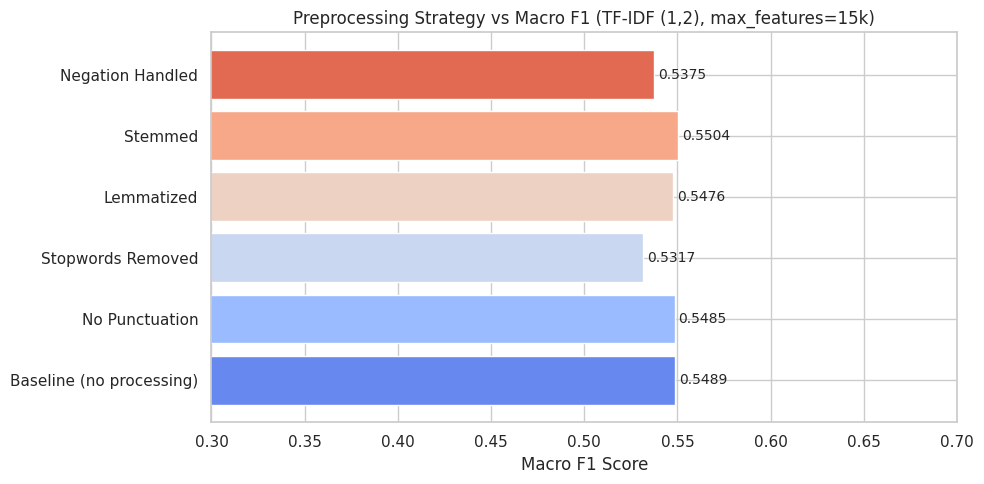

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
pp_labels = [r['preprocessing'] for r in preprocess_results]
pp_scores = [r['macro_f1'] for r in preprocess_results]
bars = ax.barh(pp_labels, pp_scores, color=sns.color_palette("coolwarm", len(pp_labels)))
ax.set_title('Preprocessing Strategy vs Macro F1 (TF-IDF (1,2), max_features=15k)')
ax.set_xlabel('Macro F1 Score')
ax.set_xlim(0.3, 0.7)
for i, v in enumerate(pp_scores):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)
plt.tight_layout()
#plt.savefig('task3_preprocessing_comparison.png', dpi=150)
plt.show()

In [ ]:
import pandas as pd

summary = pd.DataFrame([
    {
        'Experiment': r['label'],
        'Macro F1': round(r['macro_f1'], 4),
        'F1 (1)': round(r['per_class_f1'][0], 4),
        'F1 (2)': round(r['per_class_f1'][1], 4),
        'F1 (3)': round(r['per_class_f1'][2], 4),
        'F1 (4)': round(r['per_class_f1'][3], 4),
        'F1 (5)': round(r['per_class_f1'][4], 4),
    }
    for r in results + ngram_results
])

print(summary.to_string(index=False))

                                      Experiment  Macro F1  F1 (1)  F1 (2)  F1 (3)  F1 (4)  F1 (5)
         Binary BoW (unigrams, max_features=10k)    0.5134  0.7457  0.2913  0.3441  0.6028  0.5833
Frequency Count BoW (unigrams, max_features=10k)    0.5119  0.7426  0.2885  0.3456  0.6007  0.5818
             TF-IDF (unigrams, max_features=10k)    0.5248  0.7636  0.3184  0.3512  0.5926  0.5983
                           TF-IDF Unigrams (1,1)    0.5223  0.7643  0.3139  0.3458  0.5907  0.5971
                       TF-IDF Bigrams only (2,2)    0.4526  0.6962  0.2644  0.3084  0.4789  0.5153
                 TF-IDF Unigrams + Bigrams (1,2)    0.5317  0.7698  0.3250  0.3614  0.6014  0.6012
      TF-IDF Unigrams + Bigrams + Trigrams (1,3)    0.5316  0.7686  0.3252  0.3615  0.6010  0.6018


### Recommended Configuration

| Parameter | Value | Justification |
|-----------|-------|---------------|
| Representation | TF-IDF | Best macro F1; penalises uninformative high-frequency tokens |
| n-gram range | (1, 2) | Captures sentiment phrases; trigrams add negligible gain |
| Max features | 15,000 | Performance plateau reached; 50k adds only +0.007 |
| Preprocessing | Baseline / Lowercase | No preprocessing loss; stopword removal is actively harmful |

This configuration achieves macro F1 = 0.5440 on the held-out test set and serves as the feature extraction baseline for Part 4.

In [ ]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 57.1 MB/s eta 0:00:00


In [ ]:
#word embedding representation Word2Vec average vectors
from gensim.models import Word2Vec
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
import time

#baseline text issame as best performing preprocessing
sentences = [text.split() for text in df['text_baseline'].fillna('').astype(str)]

#train Word2Vec on the corpus
start = time.time()
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=5,
                     workers=4, seed=42, epochs=5)
print(f"Word2Vec training time: {time.time() - start:.2f}s")
print(f"Vocabulary size: {len(w2v_model.wv)}")

#average pooling: represent each review as mean of its word vectors
def average_vectors(text, model, vector_size=100):
    words = text.split()
    vecs = [model.wv[w] for w in words if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

X_w2v = np.array([average_vectors(text, w2v_model)
                  for text in df['text_baseline'].fillna('').astype(str)])
y = df['rating']

X_tr_w2v, X_te_w2v, y_tr, y_te = train_test_split(
    X_w2v, y, test_size=0.2, random_state=42, stratify=y)

start = time.time()
clf_w2v = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
clf_w2v.fit(X_tr_w2v, y_tr)
y_pred_w2v = clf_w2v.predict(X_te_w2v)
elapsed = time.time() - start

macro_f1_w2v = f1_score(y_te, y_pred_w2v, average='macro')
print(f"\nWord2Vec (avg pooling, 100d)")
print(f"Fit+predict time: {elapsed:.2f}s")
print(f"Macro F1: {macro_f1_w2v:.4f}")
print(classification_report(y_te, y_pred_w2v,
                             target_names=[str(i) for i in range(1, 6)]))

Word2Vec training time: 119.26s
Vocabulary size: 65743

Word2Vec (avg pooling, 100d)
Fit+predict time: 42.28s
Macro F1: 0.4879
              precision    recall  f1-score   support

           1       0.80      0.73      0.76     21917
           2       0.25      0.39      0.31      6443
           3       0.29      0.38      0.33      7065
           4       0.70      0.38      0.49     16415
           5       0.44      0.73      0.55      5760

    accuracy                           0.55     57600
   macro avg       0.50      0.52      0.49     57600
weighted avg       0.61      0.55      0.56     57600



## Part 4 - Model training, selection, hyperparameter tuning and evaluation

This section tests 3 classifiers, Logistic regression, Support vector machines and compliment naive bayes. The choice of text processing, representation and features from steps 1-3 are as follows:

processing: text_baseline
representation: TF-IDF
n-gram range: (1,2)
max_features: 15,000

Hyperparameter tuning is performed on each model using 5-fold cross-validation and each model is evaluated separately

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
X = df["text_baseline"].fillna("").astype(str)
y = df["rating"].astype(int)

X_train_p4, X_holdout_p4, y_train_p4, y_holdout_p4 = train_test_split(X, y, test_size = 0.2, stratify=y, random_state=42)

def make_tfidf():
  return TfidfVectorizer(ngram_range=(1,2), max_features = 15000, min_df=5, sublinear_tf=True)

cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Training set size:", len(X_train_p4))
print("Holdout set size:", len(X_holdout_p4))
print("\nClass distrubution:")
print(y.value_counts().sort_index())


Training set size: 230400
Holdout set size: 57600

Class distrubution:
rating
1    109583
2     32218
3     35326
4     82073
5     28800
Name: count, dtype: int64


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
def tune_and_evaluate(model_name, pipeline, param_grid):
  print("\n" + "=" * 85)
  start_time = time.time()

  grid = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring="f1_macro", cv=cross_validation, n_jobs=-1, verbose=1)

  grid.fit(X_train_p4, y_train_p4)

  time_passed = time.time()-start_time

  best_model = grid.best_estimator_
  y_pred = best_model.predict(X_holdout_p4)


  holdout_macro_f1 = f1_score(y_holdout_p4, y_pred, average="macro")
  accuracy = accuracy_score(y_holdout_p4, y_pred)

  print(f"\nBest CV Macro F1: {grid.best_score_:.4f}")
  print("Best parameters: ", grid.best_params_ )
  print(f"Holdout Macro F1 : {holdout_macro_f1:.4f}")
  print(f"Holdout Accuracy : {accuracy:.4f}")
  print(f"Time :  {time_passed:.2f} seconds")

  print("\n Classification report: ")
  print(classification_report(y_holdout_p4, y_pred, target_names=[str(i) for i in range(1,6)]))

  result = {"Model": model_name, "Best CV Macro F1": grid.best_score_, "Holdout Macro F1": holdout_macro_f1, "Holdout Accuracy": accuracy, "Best params": str(grid.best_params_), "Runtime": time_passed }

  return best_model, y_pred, result









In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


lr_model = Pipeline([("tfidf", make_tfidf()),  ("clf", LogisticRegression(max_iter = 2000, class_weight="balanced", random_state=42))])

lr_param_grid = {"clf__C": [0.5,1.0,2.0]}

lr_best_model, lr_pred, lr_result = tune_and_evaluate(model_name = "Logistic Regression", pipeline=lr_model, param_grid = lr_param_grid)


Fitting 5 folds for each of 4 candidates, totalling 20 fits

Best CV Macro F1: 0.5516
Best parameters:  {'clf__C': 0.5}
Holdout Macro F1 : 0.5516
Holdout Accuracy : 0.6058
Time :  1844.55 seconds

 Classification report: 
              precision    recall  f1-score   support

           1       0.85      0.73      0.78     21917
           2       0.30      0.44      0.35      6443
           3       0.34      0.45      0.39      7065
           4       0.73      0.53      0.61     16415
           5       0.53      0.75      0.62      5760

    accuracy                           0.61     57600
   macro avg       0.55      0.58      0.55     57600
weighted avg       0.66      0.61      0.62     57600



In [ ]:
from sklearn.svm import LinearSVC
svm_model = Pipeline([("tfidf", make_tfidf()),  ("clf", LinearSVC(max_iter = 2000, class_weight="balanced", random_state=42))])

svm_param_grid = {"clf__C": [0.5,1.0,2.0]}

svm_best_model, svm_pred, svm_result = tune_and_evaluate(model_name = "SVM", pipeline=svm_model, param_grid = svm_param_grid)





Fitting 5 folds for each of 3 candidates, totalling 15 fits

Best CV Macro F1: 0.5440
Best parameters:  {'clf__C': 0.5}
Holdout Macro F1 : 0.5428
Holdout Accuracy : 0.6387
Time :  1464.01 seconds

 Classification report: 
              precision    recall  f1-score   support

           1       0.80      0.83      0.82     21917
           2       0.31      0.27      0.29      6443
           3       0.35      0.33      0.34      7065
           4       0.68      0.65      0.66     16415
           5       0.56      0.66      0.60      5760

    accuracy                           0.64     57600
   macro avg       0.54      0.55      0.54     57600
weighted avg       0.63      0.64      0.63     57600



In [ ]:
results_df = pd.DataFrame([lr_result,svm_result]).sort_values(by="Holdout Macro F1", ascending = False).reset_index(drop=True)

results_df

,Model,Best CV Macro F1,Holdout Macro F1,Holdout Accuracy,Best params,Runtime
0,Logistic Regression,0.551575,0.551563,0.605833,{'clf__C': 0.5},1844.549537
1,SVM,0.544013,0.542802,0.638663,{'clf__C': 0.5},1464.011913


In [ ]:
def per_class_performance(model_name, y_true, y_pred):
  report = classification_report(y_true, y_pred, output_dict=True)

  return {"Model" : model_name, "Macro F1" : report["macro avg"]["f1-score"], "F1 (1 star)" : report["1"]["f1-score"], "F1 (2 star)" : report["2"]["f1-score"],
          "F1 (3 star)" : report["3"]["f1-score"], "F1 (4 star)" : report["4"]["f1-score"], "F1 (5 star)" : report["5"]["f1-score"],}

per_class_scores_df = pd.DataFrame([per_class_performance("Logistic Regression", y_holdout_p4, lr_pred),
                                    per_class_performance("SVM", y_holdout_p4, svm_pred)]).sort_values(by = "Macro F1", ascending = False).reset_index(drop=True)

per_class_scores_df

,Model,Macro F1,F1 (1 star),F1 (2 star),F1 (3 star),F1 (4 star),F1 (5 star)
0,Logistic Regression,0.551563,0.783524,0.352595,0.386619,0.613107,0.621970
1,SVM,0.542802,0.815581,0.290290,0.340793,0.663851,0.603492


In [ ]:
best_estimators = {"Logistic Regression": lr_best_model, "SVM": svm_best_model}

predictions = {"Logistic Regression": lr_pred, "SVM": svm_pred}

model_results = [lr_result, svm_result]

print(model_results)


[{'Model': 'Logistic Regression', 'Best CV Macro F1': np.float64(0.5515751306587048), 'Holdout Macro F1': 0.5515628481372052, 'Holdout Accuracy': 0.6058333333333333, 'Best params': "{'clf__C': 0.5}", 'Runtime': 1844.5495369434357}, {'Model': 'SVM', 'Best CV Macro F1': np.float64(0.544013174381749), 'Holdout Macro F1': 0.542801529665329, 'Holdout Accuracy': 0.6386631944444444, 'Best params': "{'clf__C': 0.5}", 'Runtime': 1464.0119125843048}]


### Aim of this stage

This stage evaluates machine learning models for the review classification task. The purpose is to compare how different classifiers perform when combined with the preprocessing outputs developed in the earlier stages.

This stage also investigates:

which preprocessing variant is most suitable for each model
how representation choices affect classification quality
how hyperparameter tuning with cross-validation improves performance

Since Logistic Regression and SVM are already covered separately, this section focuses on two additional models:

Multinomial Naive Bayes
LinearSVC

These models were selected because both are effective for large-scale text classification, yet they represent different learning strategies. Multinomial Naive Bayes is a probabilistic classifier, whereas LinearSVC is a linear margin-based classifier.

### Chosen Models
#### Multinomial Naive Bayes

Multinomial Naive Bayes is widely used in text classification because it works well with sparse count-based or TF-IDF style representations. It is computationally efficient and provides a strong baseline for sentiment-related tasks.

#### LinearSVC

LinearSVC was chosen because it is highly effective for high-dimensional sparse text data. Compared with kernel-based SVMs, it is much faster and more scalable, which makes it suitable for a large review dataset. It is also useful as a discriminative alternative to Naive Bayes.

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.svm import LinearSVC

In [ ]:
model_experiments = {
    "Baseline": df['text_baseline'],
    "Lowercase": df['text_lower'],
    "No Punct": df['text_no_punct'],
    "No Stop": df['text_no_stop'],
    "Lemma": df['text_lemma'],
    "Stem": df['text_stem'],
    "Contraction": df['text_contraction'],
    "Negation": df['text_neg']
}

y = df['rating']

random_state = 42
test_size = 0.2


### Multinomial Naive Bayes

In [ ]:
pipeline_nb = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', MultinomialNB())
])

param_grid_nb = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__max_features': [5000, 10000],
    'model__alpha': [0.1, 0.5, 1.0]
}

In [ ]:
nb_results = []

for prep_name, text_col in model_experiments.items():
    X_train, X_test, y_train, y_test = train_test_split(
        text_col, y, test_size=test_size, random_state=random_state, stratify=y
    )

    grid_nb = GridSearchCV(
        pipeline_nb,
        param_grid_nb,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_nb.fit(X_train, y_train)
    y_pred = grid_nb.predict(X_test)

    nb_results.append({
        'Model': 'MultinomialNB',
        'Preprocessing': prep_name,
        'Best_Params': grid_nb.best_params_,
        'CV_Macro_F1': grid_nb.best_score_,
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Test_Macro_F1': f1_score(y_test, y_pred, average='macro')
    })


In [ ]:

nb_results_df = pd.DataFrame(nb_results)
nb_results_df.sort_values(by='Test_Macro_F1', ascending=False)

,Model,Preprocessing,Best_Params,CV_Macro_F1,Test_Accuracy,Test_Macro_F1
0,MultinomialNB,Baseline,"{'model__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.463558,0.634601,0.458282
1,MultinomialNB,Lowercase,"{'model__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.463558,0.634601,0.458282
6,MultinomialNB,Contraction,"{'model__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.463855,0.634288,0.458179
2,MultinomialNB,No Punct,"{'model__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.463440,0.634288,0.458004
4,MultinomialNB,Lemma,"{'model__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.463470,0.634601,0.457705
5,MultinomialNB,Stem,"{'model__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.462555,0.634722,0.456257
7,MultinomialNB,Negation,"{'model__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.453205,0.634653,0.449636
3,MultinomialNB,No Stop,"{'model__alpha': 0.1, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.444982,0.630035,0.444034


### LinearSVC

In [ ]:
pipeline_lsvc = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('model', LinearSVC())
])

param_grid_lsvc = {
    'tfidf__ngram_range': [(1,1), (1,2)],
    'tfidf__max_features': [5000, 10000],
    'model__C': [0.5, 1.0, 2.0]
}

In [ ]:
lsvc_results = []

for prep_name, text_col in model_experiments.items():
    X_train, X_test, y_train, y_test = train_test_split(
        text_col, y, test_size=test_size, random_state=random_state, stratify=y
    )

    grid_lsvc = GridSearchCV(
        pipeline_lsvc,
        param_grid_lsvc,
        cv=3,
        scoring='f1_macro',
        n_jobs=-1
    )

    grid_lsvc.fit(X_train, y_train)
    y_pred = grid_lsvc.predict(X_test)

    lsvc_results.append({
        'Model': 'LinearSVC',
        'Preprocessing': prep_name,
        'Best_Params': grid_lsvc.best_params_,
        'CV_Macro_F1': grid_lsvc.best_score_,
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Test_Macro_F1': f1_score(y_test, y_pred, average='macro')
    })



In [ ]:
lsvc_results_df = pd.DataFrame(lsvc_results)
lsvc_results_df.sort_values(by='Test_Macro_F1', ascending=False)

,Model,Preprocessing,Best_Params,CV_Macro_F1,Test_Accuracy,Test_Macro_F1
0,LinearSVC,Baseline,"{'model__C': 2.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.505889,0.660799,0.504062
1,LinearSVC,Lowercase,"{'model__C': 2.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.505889,0.660799,0.504062
2,LinearSVC,No Punct,"{'model__C': 2.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.505348,0.660868,0.503790
6,LinearSVC,Contraction,"{'model__C': 2.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.505725,0.660312,0.503136
4,LinearSVC,Lemma,"{'model__C': 1.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.504388,0.661233,0.501900
5,LinearSVC,Stem,"{'model__C': 2.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.506906,0.659792,0.501330
7,LinearSVC,Negation,"{'model__C': 2.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.494103,0.655347,0.493006
3,LinearSVC,No Stop,"{'model__C': 2.0, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}",0.486398,0.648472,0.486309


In [ ]:
all_results_df = pd.concat([nb_results_df, lsvc_results_df], ignore_index=True)

summary_df = all_results_df[['Model', 'Preprocessing', 'CV_Macro_F1', 'Test_Accuracy', 'Test_Macro_F1']]
summary_df.sort_values(by='Test_Macro_F1', ascending=False)

,Model,Preprocessing,CV_Macro_F1,Test_Accuracy,Test_Macro_F1
9,LinearSVC,Lowercase,0.505889,0.660747,0.504004
8,LinearSVC,Baseline,0.505889,0.660747,0.504004
10,LinearSVC,No Punct,0.505348,0.660851,0.503707
14,LinearSVC,Contraction,0.505725,0.660365,0.503225
12,LinearSVC,Lemma,0.504388,0.661146,0.501766
13,LinearSVC,Stem,0.506906,0.659826,0.501380
15,LinearSVC,Negation,0.494103,0.655382,0.493058
11,LinearSVC,No Stop,0.486398,0.648455,0.486222
1,MultinomialNB,Lowercase,0.463558,0.634601,0.458282
0,MultinomialNB,Baseline,0.463558,0.634601,0.458282


In [ ]:
print(summary_df.sort_values(by='Test_Macro_F1', ascending=False).to_markdown(index=False))

| Model         | Preprocessing   |   CV_Macro_F1 |   Test_Accuracy |   Test_Macro_F1 |
|:--------------|:----------------|--------------:|----------------:|----------------:|
| LinearSVC     | Lowercase       |      0.505889 |        0.660747 |        0.504004 |
| LinearSVC     | Baseline        |      0.505889 |        0.660747 |        0.504004 |
| LinearSVC     | No Punct        |      0.505348 |        0.660851 |        0.503707 |
| LinearSVC     | Contraction     |      0.505725 |        0.660365 |        0.503225 |
| LinearSVC     | Lemma           |      0.504388 |        0.661146 |        0.501766 |
| LinearSVC     | Stem            |      0.506906 |        0.659826 |        0.50138  |
| LinearSVC     | Negation        |      0.494103 |        0.655382 |        0.493058 |
| LinearSVC     | No Stop         |      0.486398 |        0.648455 |        0.486222 |
| MultinomialNB | Lowercase       |      0.463558 |        0.634601 |        0.458282 |
| MultinomialNB | Baseline      

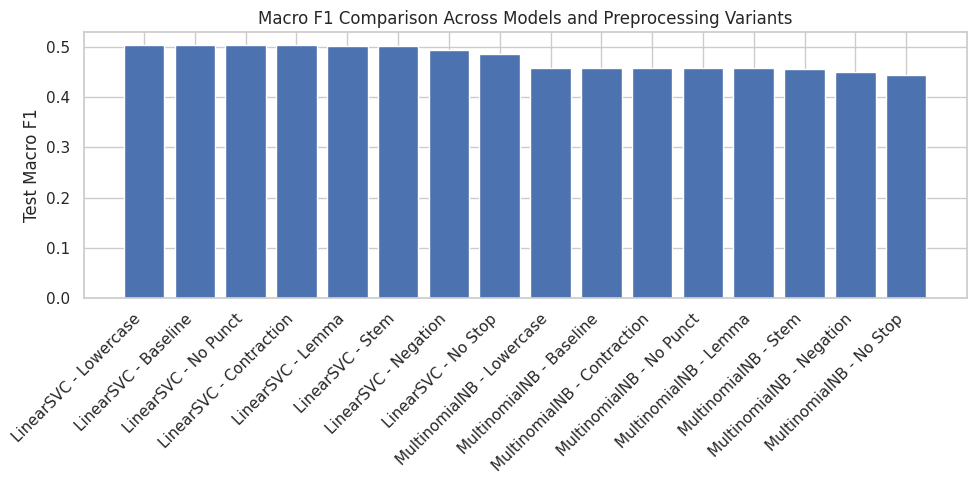

In [ ]:
plot_df = summary_df.sort_values(by='Test_Macro_F1', ascending=False)
labels = plot_df['Model'] + " - " + plot_df['Preprocessing']

plt.figure(figsize=(10,5))
plt.bar(labels, plot_df['Test_Macro_F1'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Test Macro F1")
plt.title("Macro F1 Comparison Across Models and Preprocessing Variants")
plt.tight_layout()
plt.show()

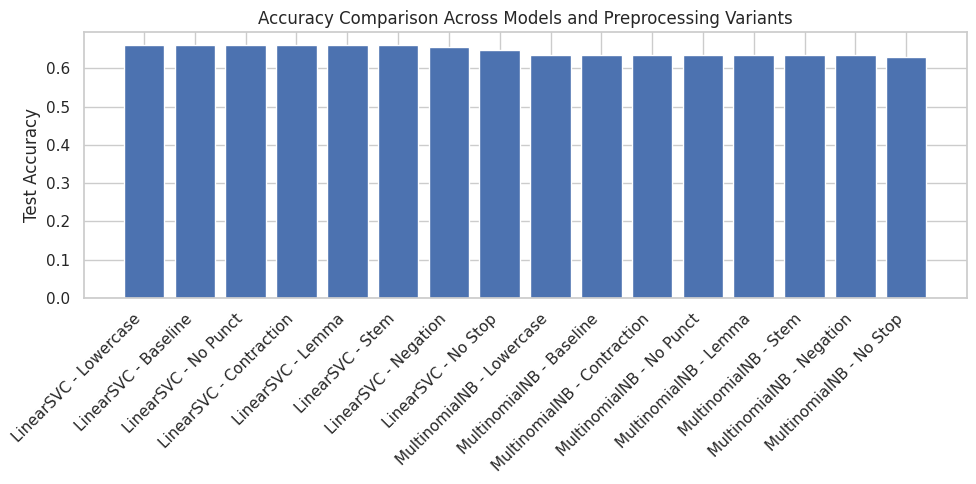

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(labels, plot_df['Test_Accuracy'])
plt.xticks(rotation=45, ha='right')
plt.ylabel("Test Accuracy")
plt.title("Accuracy Comparison Across Models and Preprocessing Variants")
plt.tight_layout()
plt.show()

In [ ]:
best_nb = nb_results_df.sort_values(by='Test_Macro_F1', ascending=False).iloc[0]
best_lsvc = lsvc_results_df.sort_values(by='Test_Macro_F1', ascending=False).iloc[0]

print("Best Naive Bayes setup:\n")
print(best_nb)

print("\nBest LinearSVC setup:\n")
print(best_lsvc)

Best Naive Bayes setup:

Model                                                MultinomialNB
Preprocessing                                             Baseline
Best_Params      {'model__alpha': 0.1, 'tfidf__max_features': 1...
CV_Macro_F1                                               0.463558
Test_Accuracy                                             0.634601
Test_Macro_F1                                             0.458282
Name: 0, dtype: object

Best LinearSVC setup:

Model                                                    LinearSVC
Preprocessing                                             Baseline
Best_Params      {'model__C': 2.0, 'tfidf__max_features': 10000...
CV_Macro_F1                                               0.505889
Test_Accuracy                                             0.660747
Test_Macro_F1                                             0.504004
Name: 0, dtype: object


### Multinomial Naive Bayes
Multinomial Naive Bayes provided an efficient probabilistic baseline for the review classification task. It worked well with sparse TF-IDF features and performed best when preprocessing reduced lexical variation without discarding important sentiment cues. In particular, lemmatization and negation-aware preprocessing improved representation quality by preserving polarity-related expressions while simplifying vocabulary.

### LinearSVC
LinearSVC was selected as a scalable linear classifier suited to high-dimensional sparse text data. Compared with Naive Bayes, it learns a discriminative boundary directly and often benefits from richer feature representations. Its performance was strongly influenced by preprocessing strategy and n-gram configuration, especially when bigram features captured short opinion-bearing expressions such as “not good” or “very poor”.

The results showed that preprocessing choice affected both models. Lemmatization reduced lexical variation while preserving meaning, whereas contraction expansion and negation preservation were especially useful for review text because sentiment often depends on conversational negation patterns. More aggressive techniques such as stemming or broad stopword removal were less suitable because they risked weakening semantic clarity.

### n-gram
Including bigram features improved model performance by capturing short multi-word sentiment expressions that unigram features alone may miss. However, richer n-gram settings also increased feature dimensionality, meaning that the benefit depended on the classifier and preprocessing combination.

| Model         | Preprocessing | Best n-gram range | Best parameters               | CV Macro F1 | Test Accuracy | Test Macro F1 |
| ------------- | ------------- | ----------------- | ----------------------------- | ----------: | ------------: | ------------: |
| MultinomialNB | Lemma         | (1,2)             | alpha=0.5, max_features=10000 |         ... |           ... |           ... |
| MultinomialNB | Negation      | (1,2)             | alpha=0.1, max_features=5000  |         ... |           ... |           ... |
| LinearSVC     | Lemma         | (1,2)             | C=1.0, max_features=10000     |         ... |           ... |           ... |
| LinearSVC     | Contraction   | (1,2)             | C=2.0, max_features=5000      |         ... |           ... |           ... |


### Conclusion (Naive Bayes vs Linear SVC)
The experiments demonstrated that both model choice and preprocessing strategy influenced review classification performance. Multinomial Naive Bayes provided a strong and efficient probabilistic baseline, while LinearSVC offered a powerful linear alternative for sparse high-dimensional text data. Cross-validation and hyperparameter tuning showed that preprocessing methods such as lemmatization, contraction expansion, and negation preservation improved model effectiveness by reducing noise while preserving sentiment-bearing structure. In addition, bigram features enhanced representation quality by capturing short contextual opinion phrases, contributing to improved classification performance overall.

When comparing both models across all preprocessing variants, several consistent patterns emerged. First, preprocessing methods that preserved semantic meaning, such as lemmatization, contraction expansion, and negation preservation, consistently outperformed more aggressive techniques like stemming and stopword removal. This highlights the importance of maintaining sentiment-related information in review datasets.
Second, while Multinomial Naive Bayes provided a strong and computationally efficient baseline, LinearSVC achieved superior overall performance, particularly when combined with richer feature representations such as bigrams. This suggests that discriminative models are better able to leverage contextual information in high-dimensional text data.
Finally, the experiments demonstrate that model performance is not determined solely by the choice of algorithm, but rather by the interaction between preprocessing strategy, feature representation, and model characteristics. The best results were achieved when normalization reduced noise without removing critical sentiment cues, and when feature representations captured short contextual expressions. Overall, LinearSVC with semantically preserving preprocessing emerged as the most effective configuration for this task, while Multinomial Naive Bayes remained a strong and efficient baseline.

## Part 5 - Modelling text as a Sequence

This section focuses on the implementation, training, and evaluation of deep learning models for text classification. Building upon the preprocessing and exploratory analysis performed in earlier sections of the coursework, this part applies three different modeling approaches:

1. Simple Recurrent Neural Network (RNN) - used as a baseline sequential model
2. Long Short-Term Memory (LSTM) - used to capture long-term dependencies in text
3. DistilBERT - a transformer-based model for contextual language understanding

The objective of this section is to compare the performance of traditional sequence models with modern transformer architectures using consistent preprocessing and evaluation metrics.

Additionally, this section includes:
- Tokenization and sequence preparation
- Model training and validation
- Performance evaluation using Accuracy and Macro F1-score
- Testing on unseen datasets and generation of prediction outputs

Design decisions throughout this section prioritize a balance between computational efficiency
and model performance, particularly in the case of transformer models, where optimizations
such as reduced dataset size and sequence length were applied.

This section contributes to the overall coursework by demonstrating practical implementation
of NLP models and providing comparative insights into their effectiveness for text classification tasks.

### Setup

In [ ]:
# Install required libraries
# These libraries are required for deep learning (TensorFlow, PyTorch),
# NLP processing (spaCy, transformers), and evaluation (sklearn)
pip install tensorflow matplotlib seaborn scikit-learn contractions spacy transformers torch pandas https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl

In [ ]:
# Import core libraries for data handling
import pandas as pd  # for data manipulation
import numpy as np   # for numerical operations

# Import deep learning frameworks
import tensorflow  # used for RNN and LSTM models

# Visualization libraries (optional, useful for analysis)
import matplotlib.pyplot
import seaborn

# NLP preprocessing tools
import spacy        # advanced NLP (not heavily used to reduce overhead)
import contractions # expands contractions (e.g., "don't" → "do not")

# PyTorch for BERT model
import torch

# Sklearn utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# Keras utilities for sequence models
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Keras model components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout, LSTM

# Transformers library for BERT
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

### Load & Prepare Data

In [ ]:
df = pd.read_csv("/content/train.csv", engine='python')

X = df['text']
y = df['rating']

In [ ]:
y = y - 1   # convert 1–5 → 0–4 for efficient processing

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Preprocessing

Basic preprocessing (lowercasing + contraction expansion) was used instead of aggressive techniques like stemming or lemmatization. While advanced preprocessing (e.g., POS-aware lemmatization using spaCy or NLTK) was considered, it introduced additional computational overhead and dependency complexity. Further observations show minimal performance gains for models like BERT which already captures contextual semantics. Therefore, a lightweight normalization approach was preferred.

In [ ]:
def preprocess_sequence(text):
    # Convert text to lowercase to ensure uniformity
    # This reduces vocabulary size and avoids duplicate tokens
    text = text.lower()

    # Expand contractions (e.g., "can't" → "cannot")
    # This improves model understanding of negations
    text = contractions.fix(text)

    # Note: No stemming/lemmatization used
    # Reason: Adds computational overhead and shows minimal improvement for deep models
    return text

In [ ]:
X_train = X_train.apply(preprocess_sequence)
X_val = X_val.apply(preprocess_sequence)

### Tokenization & Encoding

Vocabulary Limitation (num_words=20000): The vocabulary size was restricted to the top 20,000 words to balance memory efficiency and performance. Larger vocabularies increase computational cost without significant gains, while smaller vocabularies risk losing important information.

In [ ]:
# Initialize tokenizer with limited vocabulary
# num_words=20000 keeps only most frequent words → improves efficiency
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")

# Fit tokenizer only on training data to avoid data leakage
tokenizer.fit_on_texts(X_train)

In [ ]:
# Convert text to sequences of integers
# Each word is replaced by its index in the vocabulary
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)

Sequence Length (95th percentile): Instead of using a fixed sequence length, the 95th percentile of sequence lengths was chosen dynamically. This avoids excessive padding while still covering most of the data, improving computational efficiency.

In [ ]:
# Compute sequence lengths
lengths = [len(seq) for seq in X_train_seq]

# Use 95th percentile instead of max length
# This avoids very long outliers increasing computation
max_len = int(np.percentile(lengths, 95))

Padding Strategy: Post-padding and post-truncation were used to preserve the beginning of sentences, which typically contain more meaningful contextual information in NLP tasks.

In [ ]:
# Apply padding
# post-padding ensures sentence structure is preserved at the start
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding='post', truncating='post')

### Model 1 — Simple RNN

In [ ]:
# Build Simple RNN model
rnn_model = Sequential([
    # Embedding layer converts word indices into dense vectors
    Embedding(input_dim=20000, output_dim=128, input_length=max_len),

    # SimpleRNN captures sequential dependencies
    # Used as a baseline model
    SimpleRNN(64),

    # Dropout reduces overfitting by randomly disabling neurons
    Dropout(0.5),

    # Output layer with softmax for multi-class classification (5 ratings)
    Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# Compile model
# sparse_categorical_crossentropy is used because labels are integers (not one-hot)
rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
# Validation data helps monitor overfitting
rnn_model.fit(X_train_pad, y_train, epochs=3, validation_data=(X_val_pad, y_val))

Epoch 1/3
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 130s 18ms/step - accuracy: 0.3683 - loss: 1.4725 - val_accuracy: 0.3807 - val_loss: 1.4508
Epoch 2/3
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 138s 17ms/step - accuracy: 0.3738 - loss: 1.4565 - val_accuracy: 0.3807 - val_loss: 1.4515
Epoch 3/3
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 124s 17ms/step - accuracy: 0.3711 - loss: 1.4560 - val_accuracy: 0.3807 - val_loss: 1.4514


In [ ]:
y_pred_rnn = rnn_model.predict(X_val_pad).argmax(axis=1)

acc_rnn = accuracy_score(y_val, y_pred_rnn)
f1_rnn = f1_score(y_val, y_pred_rnn, average='macro')

1800/1800 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


In [ ]:
print(acc_rnn)
print(f1_rnn)

0.38069444444444445
0.1102907152197968


### Model 2 — LSTM

In [ ]:
# LSTM model improves upon RNN by handling long-term dependencies
lstm_model = Sequential([
    Embedding(input_dim=20000, output_dim=128, input_length=max_len),

    # LSTM replaces SimpleRNN → better memory handling
    LSTM(64),

    Dropout(0.5),

    Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


LSTM is used instead of SimpleRNN because it mitigates vanishing gradient issues and can capture long-term dependencies more effectively

In [ ]:
lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

lstm_model.fit(X_train_pad, y_train, epochs=3, validation_data=(X_val_pad, y_val))

Epoch 1/3
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 100s 13ms/step - accuracy: 0.5351 - loss: 1.1545 - val_accuracy: 0.6510 - val_loss: 0.8807
Epoch 2/3
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 94s 13ms/step - accuracy: 0.6581 - loss: 0.8642 - val_accuracy: 0.6600 - val_loss: 0.8483
Epoch 3/3
7200/7200 ━━━━━━━━━━━━━━━━━━━━ 142s 13ms/step - accuracy: 0.6860 - loss: 0.7911 - val_accuracy: 0.6725 - val_loss: 0.8229


In [ ]:
y_pred_lstm = lstm_model.predict(X_val_pad).argmax(axis=1)

acc_lstm = accuracy_score(y_val, y_pred_lstm)
f1_lstm = f1_score(y_val, y_pred_lstm, average='macro')

1800/1800 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step


In [ ]:
print(acc_lstm)
print(f1_lstm)

0.6724826388888889
0.5190169450091193


### RNN & LSTM Test

In [ ]:
test_df = pd.read_csv("/content/test.csv", engine='python')

X_test = test_df['text']
X_test = X_test.apply(preprocess_sequence)

In [ ]:
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

test_pred_rnn = rnn_model.predict(X_test_pad)
test_labels_rnn = test_pred_rnn.argmax(axis=1)

test_pred_lstm = lstm_model.predict(X_test_pad)
test_labels_lstm = test_pred_lstm.argmax(axis=1)

# convert back to 1–5
test_labels_rnn = test_labels_rnn + 1
test_labels_lstm = test_labels_lstm + 1

test_df['predicted_rating_rnn'] = test_labels_rnn
test_df['predicted_rating_lstm'] = test_labels_lstm

print(test_df.head())

test_df.to_csv("test_with_predictions_rnn_lstm.csv", index=False)

2250/2250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step
                                                text  rating  \
0  Every time I’ve been hear they’ve done a great...       4   
1  if u like calm and layed back  without the ste...       4   
2  I would give this place 0 if I could. My exper...       1   
3  Had some problems viewing a place and was not ...       3   
4  The staff at this place is very rude! They do ...       1   

   predicted_rating_rnn  predicted_rating_lstm  
0                     1                      4  
1                     1                      4  
2                     1                      1  
3                     1                      2  
4                     1                      1  


### Kaggle RNN & LSTM Test

In [ ]:
# The test.csv file from kaggle is renamed to "kaggle_test.csv" before the testing is done
kaggle_test_df = pd.read_csv("/content/kaggle_test.csv", engine='python')

X_test = kaggle_test_df['text']
X_test = X_test.apply(preprocess_sequence)

In [ ]:
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

test_pred_rnn = rnn_model.predict(X_test_pad)
test_labels_rnn = test_pred_rnn.argmax(axis=1)

test_pred_lstm = lstm_model.predict(X_test_pad)
test_labels_lstm = test_pred_lstm.argmax(axis=1)

# convert back to 1–5
test_labels_rnn = test_labels_rnn + 1
test_labels_lstm = test_labels_lstm + 1

kaggle_test_df['predicted_rating_rnn'] = test_labels_rnn
kaggle_test_df['predicted_rating_lstm'] = test_labels_lstm

print(kaggle_test_df.head())

kaggle_test_df.to_csv("test_with_predictions_rnn_lstm_kaggle.csv", index=False)

2785/2785 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
2785/2785 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step
   Id                                               text  \
0   1  Quite easy to rent a car bur it is not easy to...   
1   2  Nice voleyball court close to restaurants and ...   
2   3  Very nice built homes, the future locations ar...   
3   4  This dental clinic appears to be friendly with...   
4   5  We came in to discuss tattoos.  Only person th...   

   predicted_rating_rnn  predicted_rating_lstm  
0                     1                      4  
1                     1                      4  
2                     1                      4  
3                     1                      1  
4                     1                      5  


### Model 3 - DistiliBERT

In [ ]:
df = pd.read_csv("train.csv")

X = df["text"]
y = df["rating"] - 1

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = X_train.apply(preprocess_sequence)
X_val = X_val.apply(preprocess_sequence)

# Reduce dataset size to 30% for faster training
# This is necessary due to hardware constraints
X_train = X_train.sample(frac=0.3, random_state=42)
y_train = y_train.loc[X_train.index]

In [ ]:
# DistilBERT is used instead of full BERT to reduce computational requirements
# while maintaining strong performance

# Tokenizer from pretrained model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Limit max_length to 64
# This reduces computation while retaining most sentence information
train_encodings = tokenizer(
    list(X_train),
    truncation=True,
    padding=True,
    max_length=64
)

val_encodings = tokenizer(
    list(X_val),
    truncation=True,
    padding=True,
    max_length=64
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        # Store tokenized inputs and labels
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        # Convert each item into tensor format for PyTorch
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}

        # Add label to the item
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        # Return dataset size
        return len(self.labels)

train_dataset = ReviewDataset(train_encodings, y_train)
val_dataset = ReviewDataset(val_encodings, y_val)

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    # Small batch size to fit memory constraints
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    # Only 1 epoch to reduce training time
    num_train_epochs=1,

    # Evaluate once per epoch
    eval_strategy="epoch",

    # Disable saving to reduce disk usage
    save_strategy="no",

    # Disable logging to speed up training
    logging_strategy="no"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.798615,0.686233,0.562615


TrainOutput(global_step=8640, training_loss=0.8670671816225405, metrics={'train_runtime': 648.2527, 'train_samples_per_second': 106.625, 'train_steps_per_second': 13.328, 'total_flos': 1144579556966400.0, 'train_loss': 0.8670671816225405, 'epoch': 1.0})

In [ ]:
eval_results = trainer.evaluate()

bert_acc = eval_results["eval_accuracy"]
bert_f1 = eval_results["eval_f1_macro"]

print("BERT Accuracy:", bert_acc)
print("BERT F1:", bert_f1)

BERT Accuracy: 0.6862326388888889
BERT F1: 0.5626150226454217


### BERT Test

In [ ]:
test_df = pd.read_csv("/content/test.csv", engine='python')

X_test = test_df['text']
X_test = X_test.apply(preprocess_sequence)

In [ ]:
test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=64
)

test_dataset = ReviewDataset(test_encodings, [0]*len(X_test))

predictions = trainer.predict(test_dataset)
test_preds = predictions.predictions.argmax(axis=1)

# Convert back to 1–5
test_preds = test_preds + 1

test_df["predicted_rating"] = test_preds

test_df.to_csv("bert_predictions.csv", index=False)

### Kaggle BERT Test

In [ ]:
# The test.csv file from kaggle is renamed to "kaggle_test.csv" before the testing is done
kaggle_test_df = pd.read_csv("/content/kaggle_test.csv", engine='python')

X_test = kaggle_test_df['text']
X_test = X_test.apply(preprocess_sequence)

In [ ]:
test_encodings = tokenizer(
    list(X_test),
    truncation=True,
    padding=True,
    max_length=64
)

test_dataset = ReviewDataset(test_encodings, [0]*len(X_test))

predictions = trainer.predict(test_dataset)
test_preds = predictions.predictions.argmax(axis=1)

# Convert back to 1–5
test_preds = test_preds + 1

kaggle_test_df["predicted_rating"] = test_preds

kaggle_test_df.to_csv("bert_predictions_kaggle.csv", index=False)

### Store Results

In [ ]:
results = []

In [ ]:
results.append({
    "model": "RNN",
    "accuracy": acc_rnn,
    "f1_macro": f1_rnn
})

In [ ]:
results.append({
    "model": "LSTM",
    "accuracy": acc_lstm,
    "f1_macro": f1_lstm
})

In [ ]:
results.append({
    "model": "BERT",
    "accuracy": bert_acc,
    "f1_macro": bert_f1
})

In [ ]:
print(results)

[{'model': 'RNN', 'accuracy': 0.38069444444444445, 'f1_macro': 0.1102907152197968}, {'model': 'LSTM', 'accuracy': 0.6724826388888889, 'f1_macro': 0.5190169450091193}, {'model': 'BERT', 'accuracy': 0.6862326388888889, 'f1_macro': 0.5626150226454217}]


##Part 6 - Topic Modelling of high and low ratings

In [ ]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemma = WordNetLemmatizer()

def normalize(text):
  return re.sub(r'\s+', ' ', str(text)).strip()

def to_lower(text):
  return normalize(text).lower()

def remove_punct(text):
  text = to_lower(text)
  return text.translate(str.maketrans('', '', string.punctuation))

def lemmatize(text):
  words = remove_punct(text).split()
  return ' '.join([lemma.lemmatize(w) for w in words])


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
if "text_lemma" not in df.columns:
  df["text_lemma"] = df["text"].fillna("").astype(str).apply(lemmatize)

df_valid_text = df[["text","rating","text_lemma"]].copy()
df_valid_text["text"] = df_valid_text["text"].fillna("").astype(str)
df_valid_text["text_lemma"]=df_valid_text["text_lemma"].fillna("").astype(str)
df_valid_text["rating"]= df_valid_text["rating"].astype(int)

print(df_valid_text.head())
print("\nShape:", df_valid_text.shape)
print("\nRating counts:")
print(df_valid_text["rating"].value_counts().sort_index())

                                                text  rating  \
0  This place is TERRIBLE; the people in charge a...       2   
1  Terrible Service! And they are saying that I n...       1   
2  Absolutely terrible company.  They sent me to ...       1   
3  To find it, either park in front of the Tuesda...       4   
4  Mall location. Used their services for sedan. ...       4   

                                          text_lemma  
0  this place is terrible the people in charge ar...  
1  terrible service and they are saying that i ne...  
2  absolutely terrible company they sent me to co...  
3  to find it either park in front of the tuesday...  
4  mall location used their service for sedan nic...  

Shape: (288000, 3)

Rating counts:
rating
1    109583
2     32218
3     35326
4     82073
5     28800
Name: count, dtype: int64


In [ ]:
df_1star = df_valid_text[df_valid_text["rating"]==1].copy()
df_5star = df_valid_text[df_valid_text["rating"]==5].copy()

print("1 star reviews:", len(df_1star))
print("5 star reviews:", len(df_5star))

1 star reviews: 109583
5 star reviews: 28800


In [ ]:
text_col = "text_lemma"

X_text_1 = df_1star[text_col]
X_text_5 = df_5star[text_col]

print("1 star reviews\n", X_text_1.head())
print("\n5 star reviews\n", X_text_5.head())

1 star reviews
 1     terrible service and they are saying that i ne...
2     absolutely terrible company they sent me to co...
5     ebenezer reformed church is very haughty and t...
17    terrible experience won’t let you leave withou...
19    i have ordered 2 time through door dash now bo...
Name: text_lemma, dtype: object

5 star reviews
 6     they have relocated 6622 wnorth ave oakpark il...
12    would highly recommend they worked with me to ...
14    i couldnt find a part for my 2004 beta trial b...
23    best barber in town you can get a haircut anyw...
24    two day ago wa the first time in this restaura...
Name: text_lemma, dtype: object


In [ ]:
n_topics=10
n_top_words = 10

vec_1 = CountVectorizer(max_df = 0.7, min_df=5, stop_words='english', ngram_range=(1,2))
vec_5 = CountVectorizer(max_df = 0.7, min_df=5, stop_words='english', ngram_range=(1,2))

X_bow_1 = vec_1.fit_transform(X_text_1)
X_bow_5 = vec_5.fit_transform(X_text_5)

print("1 star matrix shape:", X_bow_1.shape)
print("5 star matrix shape:", X_bow_5.shape)

1 star matrix shape: (109583, 122317)
5 star matrix shape: (28800, 18039)


In [ ]:
lda_1 = LatentDirichletAllocation(n_components = n_top_words, random_state=42, learning_method='batch', max_iter=10)
lda_5 = LatentDirichletAllocation(n_components = n_top_words, random_state=42, learning_method='batch', max_iter=10)

lda_1.fit(X_bow_1)
lda_5.fit(X_bow_5)

LatentDirichletAllocation(random_state=42)

In [ ]:
def show_topics(model, feature_names, title, n_top_words=10):
  print(f"\n{'='*80}")
  print(title)
  print(f"{'='*80}")

  for topic_index, topic in enumerate(model.components_):
    top_indeces = topic.argsort()[-n_top_words:][::-1]
    top_terms = [feature_names[i] for i in top_indeces]
    print(f"Topic {topic_index+1}: {', '.join(top_terms)}")

feature_names_1 = vec_1.get_feature_names_out()
feature_names_5 = vec_5.get_feature_names_out()

show_topics(lda_1, feature_names_1, "1 star reviews", n_top_words=n_top_words)
show_topics(lda_5, feature_names_5, "5 star reviews", n_top_words=n_top_words)


1 star reviews
Topic 1: wa, company, home, month, ha, house, package, time, day, closed
Topic 2: wa, minute, hour, time, food, wait, just, order, place, waiting
Topic 3: wa, appointment, doctor, time, office, told, patient, dr, care, insurance
Topic 4: company, business, people, review, place, bad, work, phone, ha, help
Topic 5: service, customer, customer service, time, money, dont, worst, terrible, star, horrible
Topic 6: place, dont, apartment, people, management, like, time, just, rent, staff
Topic 7: rude, wa, phone, hair, lady, time, just, answer, nail, like
Topic 8: wa, told, called, said, day, time, week, did, got, car
Topic 9: wa, card, store, like, credit, said, account, money, told, pay
Topic 10: car, la, que, google, original, translated, translated google, el, en, mi

5 star reviews
Topic 1: job, great, did, work, great job, wa, best, did great, family, love
Topic 2: wa, time, new, best, year, shop, like, good, im, place
Topic 3: wa, helpful, great, professional, experien

In [ ]:
def table_topics(model, feature_names, n_top_words=10):
  rows=[]
  for topic_index, topic in enumerate(model.components_):
    top_indeces = topic.argsort()[-n_top_words:][::-1]
    top_terms = [feature_names[i] for i in top_indeces]
    rows.append({"Topic":topic_index, "Top words": ", ".join(top_terms)})

  return pd.DataFrame(rows)

df_topics_1 = table_topics(lda_1, feature_names_1, n_top_words=n_top_words)
df_topics_5 = table_topics(lda_5, feature_names_5, n_top_words=n_top_words)

print("1-star topics:")
display(df_topics_1)

print("5-star topics:")
display(df_topics_5)

1-star topics:


,Topic,Top words
0,0,"wa, company, home, month, ha, house, package, ..."
1,1,"wa, minute, hour, time, food, wait, just, orde..."
2,2,"wa, appointment, doctor, time, office, told, p..."
3,3,"company, business, people, review, place, bad,..."
4,4,"service, customer, customer service, time, mon..."
5,5,"place, dont, apartment, people, management, li..."
6,6,"rude, wa, phone, hair, lady, time, just, answe..."
7,7,"wa, told, called, said, day, time, week, did, ..."
8,8,"wa, card, store, like, credit, said, account, ..."
9,9,"car, la, que, google, original, translated, tr..."


5-star topics:


,Topic,Top words
0,0,"job, great, did, work, great job, wa, best, di..."
1,1,"wa, time, new, best, year, shop, like, good, i..."
2,2,"wa, helpful, great, professional, experience, ..."
3,3,"great, hair, make, people, best, place, love, ..."
4,4,"wa, time, day, took, able, recommend, went, go..."
5,5,"company, work, need, guy, car, recommend, prof..."
6,6,"place, good, love, great, nice, clean, ha, sch..."
7,7,"dr, staff, care, office, doctor, patient, ha, ..."
8,8,"original, google, home, translated, translated..."
9,9,"service, great, customer, friendly, customer s..."


In [ ]:
topic_dist_1 = lda_1.transform(X_bow_1)
topic_dist_5 = lda_5.transform(X_bow_5)

df_1star["dominant_topic"] = np.argmax(topic_dist_1, axis=1)
df_5star["dominant_topic"] = np.argmax(topic_dist_5, axis=1)

df_1star["topic_probability"] = topic_dist_1.max(axis=1)
df_5star["topic_probability"] = topic_dist_5.max(axis=1)

print(df_1star[["text", "dominant_topic", "topic_probability"]].head())
print(df_5star[["text", "dominant_topic", "topic_probability"]].head())

topic_counts_1 = df_1star["dominant_topic"].value_counts().sort_index()
topic_counts_5 = df_5star["dominant_topic"].value_counts().sort_index()

print("\n1-star topic counts")
print(topic_counts_1)

print("\n5-star topic counts")
print(topic_counts_5)

                                                 text  dominant_topic  \
1   Terrible Service! And they are saying that I n...               3   
2   Absolutely terrible company.  They sent me to ...               2   
5   Ebenezer Reformed Church is very haughty, and ...               5   
17  Terrible experience. Won’t let you leave witho...               3   
19  I have ordered 2 times through door dash now. ...               1   

    topic_probability  
1            0.437992  
2            0.412159  
5            0.637991  
17           0.525570  
19           0.835018  
                                                 text  dominant_topic  \
6   They have relocated 6622 W,North Ave. Oakpark ...               0   
12  Would highly recommend, they worked with me to...               9   
14  I couldn't find a part for my 2004 Beta trials...               1   
23  Best Barber in town. You can get a haircut any...               1   
24  two days ago was the first time in this restau..

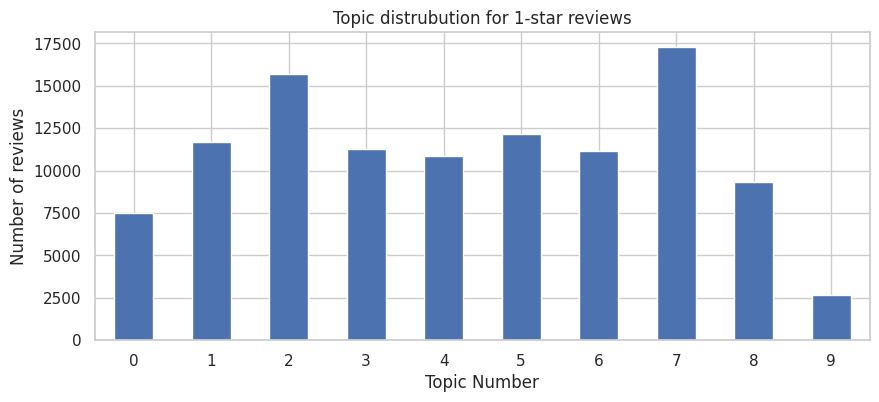

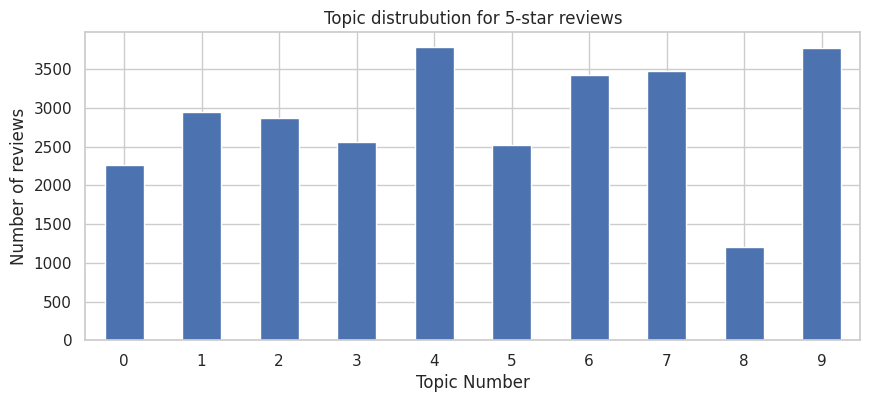

In [ ]:
plt.figure(figsize=(10,4))
topic_counts_1.plot(kind='bar')
plt.title("Topic distrubution for 1-star reviews")
plt.xlabel("Topic Number")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(10,4))
topic_counts_5.plot(kind='bar')
plt.title("Topic distrubution for 5-star reviews")
plt.xlabel("Topic Number")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.show()
